# HNDSR - Hybrid Neural Operator-Diffusion Super-Resolution
## With MLflow Experiment Tracking

This notebook integrates **MLflow** for full experiment tracking into the HNDSR training pipeline.

**MLflow features used:**
- `mlflow.log_params()` — Hyperparameters (learning rate, epochs, batch size, model config)
- `mlflow.log_metric()` — Per-epoch train/val loss, PSNR, SSIM
- `mlflow.log_artifact()` — Checkpoint files (.pth)
- `mlflow.pytorch.log_model()` — Full model logging for registry

All checkpoints and MLflow tracking data are saved inside the `MLFlow/` folder.

## Complete Hyperparameters Reference

| Category | Parameter | Value | Rationale |
|----------|-----------|-------|-----------|
| **Model — Autoencoder** | `latent_dim` | 128 | Balances compression vs. reconstruction fidelity |
| | `downsample_ratio` | 8 | 3 strided convolutions → 64×64 HR → 8×8 latent |
| | `num_res_blocks` | 4 | Sufficient depth without excessive parameters |
| **Model — FNO** | `modes` | 8 | Number of Fourier modes retained per dimension |
| | `width` | 32 | Channel width of spectral conv layers |
| | Spectral layers | 4 | Each layer: spectral conv + pointwise conv + GELU |
| **Model — Implicit Amp** | `hidden_dim` | 256 | 3-layer MLP: 1 → 256 → 256 → 128 → Sigmoid |
| **Model — DiffusionUNet** | `model_channels` | 64 | Base channel count; doubles in downsampling |
| | `context_dim` | 128 | Must match `latent_dim` for cross-attention |
| **Diffusion Schedule** | `num_timesteps` | 1000 | Standard DDPM schedule length |
| | `beta_start` | 0.0001 | Linear schedule lower bound |
| | `beta_end` | 0.02 | Linear schedule upper bound |
| | `inference_steps` | 50 | DDIM sub-sampling for faster generation |
| **Training — Stage 1** | Epochs | 20 | AE converges quickly (deterministic L1) |
| | Learning rate | 1e-4 | AdamW with weight decay 1e-4 |
| | Loss | L1 | Sharper reconstructions than L2 |
| **Training — Stage 2** | Epochs | 15 | FNO learning in compressed latent space |
| | Learning rate | 1e-4 | Same optimizer config |
| | Loss | MSE | Standard regression in latent space |
| **Training — Stage 3** | Epochs | 30 | Diffusion needs more iterations for convergence |
| | Learning rate | 1e-4 | Same optimizer config |
| | Loss | MSE (noise) | $\|\epsilon - \epsilon_\theta\|_2^2$ |
| **Other** | `patch_size` | 64 | HR crop size (power of 2 for FFT compatibility) |
| | `batch_size` | 2 | Memory-constrained (diffusion + FNO) |
| | Scheduler | CosineAnnealingLR | Smooth LR decay to 0 over each stage |
| | Seed | 42 | Reproducibility |

## Cell 1: Install Dependencies

Installs all required packages. Key packages:
- **torch / torchvision** — PyTorch deep learning framework and image utilities
- **lpips** — Learned Perceptual Image Patch Similarity (AlexNet-based perceptual metric)
- **timm / einops** — Model utilities (commonly co-installed)
- **mlflow** — Experiment tracking, metric logging, model registry

In [2]:
# Cell 1: Install Dependencies
%pip install torch torchvision lpips timm einops mlflow scikit-image matplotlib tqdm -q

Note: you may need to restart the kernel to use updated packages.


## Cell 2: Imports

**Line-by-line breakdown:**

- `torch`, `torch.nn`, `torch.nn.functional` — Core PyTorch: tensor ops, layers, activation functions
- `torch.utils.data.Dataset / DataLoader` — Custom dataset and batched iteration
- `torch.amp` — Automatic Mixed Precision (imported but not used — cuFFT requires float32)
- `torchvision.transforms` — Image preprocessing (normalize to [-1, 1])
- `torchvision.utils.save_image` — Save tensor as PNG during evaluation
- `numpy`, `math` — Numerical operations and constants
- `pathlib.Path` — OS-agnostic file path handling
- `PIL.Image` — Load images from disk
- `tqdm` — Progress bars for training loops
- `lpips` — Learned perceptual metric (AlexNet backbone)
- `skimage.metrics` — Reference implementations of PSNR and SSIM
- `matplotlib.pyplot` — Plotting training curves and comparison grids
- `mlflow`, `mlflow.pytorch` — Experiment tracking and PyTorch model logging
- `set_seed(42)` — Ensures reproducibility across random, numpy, and torch
- `PYTORCH_CUDA_ALLOC_CONF` — Enables expandable CUDA memory segments to reduce fragmentation

In [3]:
# Cell 2: Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import torchvision.transforms as transforms
from torchvision.utils import save_image

import numpy as np
import math
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import lpips
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import os
import random
import gc

# MLflow imports
import mlflow
import mlflow.pytorch

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# Memory optimization
torch.cuda.empty_cache()
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

C:\Users\harsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU Memory: 6.44 GB


## Cell 3: MLflow Configuration & Checkpoint Setup

All checkpoints, evaluation results, and MLflow tracking data are saved inside **`MLFlow/`**.

**Line-by-line breakdown:**

- `MLFLOW_DIR` — Resolves to the current notebook's directory (`MLFlow/`)
- `CHECKPOINT_DIR` — Same as `MLFLOW_DIR`; all `.pth` files are saved here
- `AUTOENCODER_PATH`, `NEURAL_OPERATOR_PATH`, `DIFFUSION_PATH` — Per-stage best checkpoint paths
- `COMPLETE_MODEL_PATH` — Final combined checkpoint with all four component state dicts
- `EVAL_RESULTS_DIR` — Directory for evaluation output images (LR/SR/HR samples)
- `mlflow.set_tracking_uri(...)` — Points MLflow to a local `mlruns/` directory (no server needed)
- `mlflow.set_experiment('HNDSR_SuperResolution')` — Creates or selects the experiment by name

In [4]:
# Cell 3: MLflow Setup & Checkpoint Paths
import os
from pathlib import Path

# All files are saved inside this folder
MLFLOW_DIR = os.path.dirname(os.path.abspath('__file__'))  # Current notebook directory (MLFlow/)
CHECKPOINT_DIR = MLFLOW_DIR

# Ensure directory exists
Path(CHECKPOINT_DIR).mkdir(parents=True, exist_ok=True)

# Checkpoint paths — all inside MLFlow/
AUTOENCODER_PATH = os.path.join(CHECKPOINT_DIR, 'autoencoder_best.pth')
NEURAL_OPERATOR_PATH = os.path.join(CHECKPOINT_DIR, 'neural_operator_best.pth')
DIFFUSION_PATH = os.path.join(CHECKPOINT_DIR, 'diffusion_best.pth')
COMPLETE_MODEL_PATH = os.path.join(CHECKPOINT_DIR, 'hndsr_complete.pth')
EVAL_RESULTS_DIR = os.path.join(CHECKPOINT_DIR, 'evaluation_results')

# MLflow configuration — tracking URI points to MLFlow/ folder
MLFLOW_TRACKING_URI = os.path.join(MLFLOW_DIR, 'mlruns')
mlflow.set_tracking_uri(f'file:///{MLFLOW_TRACKING_URI}')
mlflow.set_experiment('HNDSR_SuperResolution')

print("=" * 70)
print("MLflow + HNDSR Configuration")
print("=" * 70)
print(f"\n📁 Working directory:    {MLFLOW_DIR}")
print(f"📁 Checkpoint directory: {CHECKPOINT_DIR}")
print(f"📁 MLflow tracking URI:  {MLFLOW_TRACKING_URI}")
print(f"\n📄 Autoencoder:       {AUTOENCODER_PATH}")
print(f"📄 Neural Operator:   {NEURAL_OPERATOR_PATH}")
print(f"📄 Diffusion:         {DIFFUSION_PATH}")
print(f"📄 Complete Model:    {COMPLETE_MODEL_PATH}")
print(f"📄 Eval Results:      {EVAL_RESULTS_DIR}")
print("=" * 70)

C:\Users\harsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/03/03 04:25:37 INFO mlflow.tracking.fluent: Experiment with name 'HNDSR_SuperResolution' does not exist. Creating a new experiment.


MLflow + HNDSR Configuration

📁 Working directory:    c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow
📁 Checkpoint directory: c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow
📁 MLflow tracking URI:  c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow\mlruns

📄 Autoencoder:       c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow\autoencoder_best.pth
📄 Neural Operator:   c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow\neural_operator_best.pth
📄 Diffusion:         c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow\diffusion_best.pth
📄 Complete Model:    c:\Users\

## Cell 4–5: Dataset Configuration & Verification

Set the paths to your HR and LR image directories. The notebook auto-detects Kaggle environments.

**Dataset:** [4× Satellite Image Super-Resolution](https://www.kaggle.com/datasets/cristobaltudela/4x-satellite-image-super-resolution) by Cristobal Tudela — paired HR/LR satellite images at 4× downscaling factor.

**Cell 5 (`check_dataset_paths`)** verifies that both directories exist, counts available images, and lists file extensions for quick debugging.

In [6]:
# Cell 4: Set Dataset Paths
# ============================================================
# UPDATE THESE PATHS to point to your dataset
# ============================================================
HR_DIR = r'C:\Users\harsh\.cache\kagglehub\datasets\cristobaltudela\4x-satellite-image-super-resolution\versions\1\HR_0.5m\HR_0.5m'
LR_DIR = r'C:\Users\harsh\.cache\kagglehub\datasets\cristobaltudela\4x-satellite-image-super-resolution\versions\1\LR_2m\LR_2m'
# ============================================================

# Auto-detect Kaggle environment
if not HR_DIR or not LR_DIR:
    kaggle_input = Path('/kaggle/input')
    if kaggle_input.exists():
        print('🔍 Kaggle environment detected, searching for dataset...')
        for dataset_dir in kaggle_input.iterdir():
            if dataset_dir.is_dir():
                for item in dataset_dir.rglob('*'):
                    if item.is_dir() and item.name.lower() in ['hr', 'high']:
                        HR_DIR = str(item)
                    if item.is_dir() and item.name.lower() in ['lr', 'low']:
                        LR_DIR = str(item)
        if HR_DIR and LR_DIR:
            print(f'✅ Found HR: {HR_DIR}')
            print(f'✅ Found LR: {LR_DIR}')
        else:
            print('❌ Could not auto-detect. Please set HR_DIR and LR_DIR manually.')
    else:
        print('⚠️  Please set HR_DIR and LR_DIR above before running training.')
else:
    print(f'✅ HR: {HR_DIR}')
    print(f'✅ LR: {LR_DIR}')

✅ HR: C:\Users\harsh\.cache\kagglehub\datasets\cristobaltudela\4x-satellite-image-super-resolution\versions\1\HR_0.5m\HR_0.5m
✅ LR: C:\Users\harsh\.cache\kagglehub\datasets\cristobaltudela\4x-satellite-image-super-resolution\versions\1\LR_2m\LR_2m


In [7]:
# Cell 5: Check Dataset Paths
def check_dataset_paths(hr_dir, lr_dir):
    """Check if dataset paths exist and list available files"""
    print("\n" + "="*60)
    print("DATASET PATH VERIFICATION")
    print("="*60)

    hr_path = Path(hr_dir)
    lr_path = Path(lr_dir)

    print(f"\n📁 HR Directory: {hr_dir}")
    print(f"   Exists: {hr_path.exists()}")

    if hr_path.exists():
        hr_files = list(hr_path.glob('*'))
        print(f"   Total files: {len(hr_files)}")
        if hr_files:
            print(f"   First 5 files: {[f.name for f in hr_files[:5]]}")
            extensions = set([f.suffix.lower() for f in hr_files if f.is_file()])
            print(f"   File extensions: {extensions}")
    else:
        print("   ⚠️  Directory does not exist!")

    print(f"\n📁 LR Directory: {lr_dir}")
    print(f"   Exists: {lr_path.exists()}")

    if lr_path.exists():
        lr_files = list(lr_path.glob('*'))
        print(f"   Total files: {len(lr_files)}")
        if lr_files:
            print(f"   First 5 files: {[f.name for f in lr_files[:5]]}")
            extensions = set([f.suffix.lower() for f in lr_files if f.is_file()])
            print(f"   File extensions: {extensions}")
    else:
        print("   ⚠️  Directory does not exist!")

    print("\n" + "="*60)

if HR_DIR and LR_DIR:
    check_dataset_paths(HR_DIR, LR_DIR)
else:
    print('⚠️  Set HR_DIR and LR_DIR in the cell above first.')


DATASET PATH VERIFICATION

📁 HR Directory: C:\Users\harsh\.cache\kagglehub\datasets\cristobaltudela\4x-satellite-image-super-resolution\versions\1\HR_0.5m\HR_0.5m
   Exists: True
   Total files: 360
   First 5 files: ['austin1.tif', 'austin10.tif', 'austin11.tif', 'austin12.tif', 'austin13.tif']
   File extensions: {'.tif'}

📁 LR Directory: C:\Users\harsh\.cache\kagglehub\datasets\cristobaltudela\4x-satellite-image-super-resolution\versions\1\LR_2m\LR_2m
   Exists: True
   Total files: 360
   First 5 files: ['austin1.tif', 'austin10.tif', 'austin11.tif', 'austin12.tif', 'austin13.tif']
   File extensions: {'.tif'}



## Cell 6: SatelliteDataset (Paper §IV.A)

Custom `torch.utils.data.Dataset` for paired satellite image super-resolution.

**Line-by-line breakdown:**

- **`__init__`** — Scans `hr_dir` and `lr_dir` for images (`.png`, `.jpg`, `.tif`, etc.). Matches HR/LR pairs by filename stem. Falls back to positional pairing if no name matches.
- **`transform`** — `ToTensor()` + `Normalize([0.5]*3, [0.5]*3)` maps pixel values from [0, 255] to [-1, 1] — the standard range for diffusion models.
- **`__getitem__` (training=True):**
  1. Loads HR and LR images as RGB PIL images.
  2. Computes `scale = hr_w // lr_w` (should be 4).
  3. Randomly crops LR to `patch_size // scale` (16×16) and HR to `patch_size` (64×64).
  4. Random horizontal flip for data augmentation.
- **`__getitem__` (training=False):**
  - Center-crops HR to `patch_size` and LR to `patch_size // 4` for deterministic evaluation.
- **Returns:** `{'lr': tensor, 'hr': tensor, 'scale': 4}`

In [8]:
# Cell 6: Dataset Class (Memory Optimized - Power of 2 patch size)
class SatelliteDataset(Dataset):
    """Dataset for satellite image super-resolution"""
    def __init__(self, hr_dir, lr_dir, patch_size=64, training=True):
        self.hr_dir = Path(hr_dir)
        self.lr_dir = Path(lr_dir)
        self.patch_size = patch_size
        self.training = training

        # Try multiple image extensions
        self.hr_images = []
        self.lr_images = []

        for ext in ['*.png', '*.jpg', '*.jpeg', '*.tif', '*.tiff', '*.PNG', '*.JPG', '*.JPEG', '*.TIF', '*.TIFF']:
            self.hr_images.extend(list(self.hr_dir.glob(ext)))
            self.lr_images.extend(list(self.lr_dir.glob(ext)))

        self.hr_images = sorted(self.hr_images)
        self.lr_images = sorted(self.lr_images)

        if len(self.hr_images) == 0 or len(self.lr_images) == 0:
            raise ValueError(
                f"No images found!\n"
                f"HR Directory: {hr_dir} ({len(self.hr_images)} images)\n"
                f"LR Directory: {lr_dir} ({len(self.lr_images)} images)\n"
                f"Please check if the paths are correct."
            )

        # Match images by filename
        hr_names = {img.stem: img for img in self.hr_images}
        lr_names = {img.stem: img for img in self.lr_images}

        # Find common images
        common_names = set(hr_names.keys()) & set(lr_names.keys())

        if len(common_names) == 0:
            print("⚠️  Warning: No matching filenames found between HR and LR directories!")
            print(f"   HR samples: {list(hr_names.keys())[:5]}")
            print(f"   LR samples: {list(lr_names.keys())[:5]}")
            min_len = min(len(self.hr_images), len(self.lr_images))
            self.hr_images = self.hr_images[:min_len]
            self.lr_images = self.lr_images[:min_len]
        else:
            self.hr_images = [hr_names[name] for name in sorted(common_names)]
            self.lr_images = [lr_names[name] for name in sorted(common_names)]

        print(f"Found {len(self.hr_images)} image pairs")
        if len(self.hr_images) > 0:
            print(f"Sample HR: {self.hr_images[0].name}")
            print(f"Sample LR: {self.lr_images[0].name}")

        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])

    def __len__(self):
        return len(self.hr_images)

    def __getitem__(self, idx):
        hr_img = Image.open(self.hr_images[idx]).convert('RGB')
        lr_img = Image.open(self.lr_images[idx]).convert('RGB')

        if self.training:
            hr_w, hr_h = hr_img.size
            lr_w, lr_h = lr_img.size
            scale = hr_w // lr_w

            lr_crop_size = self.patch_size // scale
            if lr_w > lr_crop_size and lr_h > lr_crop_size:
                x = random.randint(0, lr_w - lr_crop_size)
                y = random.randint(0, lr_h - lr_crop_size)

                lr_img = lr_img.crop((x, y, x + lr_crop_size, y + lr_crop_size))
                hr_img = hr_img.crop((x * scale, y * scale,
                                     (x + lr_crop_size) * scale,
                                     (y + lr_crop_size) * scale))

            if random.random() > 0.5:
                lr_img = lr_img.transpose(Image.FLIP_LEFT_RIGHT)
                hr_img = hr_img.transpose(Image.FLIP_LEFT_RIGHT)
        else:
            hr_img = transforms.CenterCrop(self.patch_size)(hr_img)
            lr_img = transforms.CenterCrop(self.patch_size // 4)(lr_img)

        lr_tensor = self.transform(lr_img)
        hr_tensor = self.transform(hr_img)

        return {'lr': lr_tensor, 'hr': hr_tensor, 'scale': 4}

---
## Model Architecture

### Cell 7: Latent Autoencoder (Paper §III.A)

Learns a compact latent representation $z = E_\theta(I_{HR})$ at $\frac{1}{8}$ spatial resolution.

**Loss:** $\mathcal{L}_{AE} = \|I_{HR} - D_\phi(E_\theta(I_{HR}))\|_1$

| Layer | Input | Output | Operation |
|-------|-------|--------|-----------|
| `encoder[0]` | 3 × 64 × 64 | 128 × 64 × 64 | Conv2d(3→128, k=3) |
| `encoder[1–2]` | 128 × 64 × 64 | 128 × 32 × 32 | Conv2d(128→128, k=4, s=2) + ReLU |
| `encoder[3–4]` | 128 × 32 × 32 | 128 × 16 × 16 | Conv2d(128→128, k=4, s=2) + ReLU |
| `encoder[5–6]` | 128 × 16 × 16 | 128 × 8 × 8 | Conv2d(128→128, k=4, s=2) + ReLU |
| `encoder[7–10]` | 128 × 8 × 8 | 128 × 8 × 8 | 4× ResidualBlock(128) |
| `decoder` | 128 × 8 × 8 | 3 × 64 × 64 | Mirror of encoder + Tanh |

**Line-by-line breakdown:**

- **`ResidualBlock(channels)`** — Two Conv2d(3×3) layers with ReLU, plus a skip connection: $y = x + \text{Block}(x)$. This prevents gradient vanishing and preserves identity mappings.
- **`LatentAutoencoder.__init__`** — Builds encoder and decoder dynamically based on `downsample_ratio`. `num_downs = log2(8) = 3` strided convolutions.
- **`encode(x)`** → $z \in \mathbb{R}^{B \times 128 \times 8 \times 8}$ (for 64×64 input).
- **`decode(z)`** → reconstruction $\hat{I}_{HR} \in \mathbb{R}^{B \times 3 \times 64 \times 64}$.
- **`forward(x)`** → returns `(reconstruction, latent)` tuple.

In [9]:
# Cell 7: Latent Autoencoder
class ResidualBlock(nn.Module):
    """Residual block for autoencoder"""
    def __init__(self, channels, use_bn=False):
        super().__init__()
        layers = [
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1)
        ]
        if use_bn:
            layers.insert(1, nn.BatchNorm2d(channels))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return x + self.block(x)


class LatentAutoencoder(nn.Module):
    """Autoencoder for learning latent representation"""
    def __init__(self, in_channels=3, latent_dim=64, num_res_blocks=4, downsample_ratio=8):
        super().__init__()
        self.latent_dim = latent_dim
        self.downsample_ratio = downsample_ratio

        num_downs = int(math.log2(downsample_ratio))

        # Encoder
        encoder_layers = [nn.Conv2d(in_channels, latent_dim, 3, padding=1)]
        channels = latent_dim
        for i in range(num_downs):
            out_channels = min(channels * 2, 128)
            encoder_layers.extend([
                nn.Conv2d(channels, out_channels, 4, stride=2, padding=1),
                nn.ReLU(inplace=True)
            ])
            channels = out_channels

        for _ in range(num_res_blocks):
            encoder_layers.append(ResidualBlock(channels))

        self.encoder = nn.Sequential(*encoder_layers)

        # Decoder
        decoder_layers = []
        for i in range(num_res_blocks):
            decoder_layers.append(ResidualBlock(channels))

        for i in range(num_downs):
            out_channels = channels // 2
            decoder_layers.extend([
                nn.ConvTranspose2d(channels, out_channels, 4, stride=2, padding=1),
                nn.ReLU(inplace=True)
            ])
            channels = out_channels

        decoder_layers.append(nn.Conv2d(channels, in_channels, 3, padding=1))
        decoder_layers.append(nn.Tanh())

        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z)
        return recon, z

### Cell 8: Neural Operator — FNO (Paper §III.B)

Fourier Neural Operator with spectral convolutions. Maps LR input to a structure-aware latent prior $z_{prior} = N_\psi(E_\theta(I_{LR}), s)$.

**Loss:** $\mathcal{L}_{NO} = \|z_{HR} - \hat{z}_{NO}\|_2^2$

**Key idea:** Standard CNNs learn spatial filters → local receptive fields. FNOs learn filters in the **frequency domain** via FFT → each layer captures global patterns across the entire image. This is why the neural operator can learn resolution-invariant mappings.

**Line-by-line breakdown:**

- **`SpectralConv2d`** — The core FNO building block:
  1. `torch.fft.rfft2(x)` — 2D real FFT → frequency-domain representation.
  2. Learnable weights multiply the lowest `modes` frequency coefficients (truncated spectral convolution).
  3. `torch.fft.irfft2(...)` — Inverse FFT back to spatial domain.
  4. **Critical fix:** Forces `float32` for FFT operations to avoid cuFFT half-precision limitations.
- **`NeuralOperator.__init__`** — 4 spectral conv layers, each with a parallel pointwise conv (`w0`–`w3`) and GELU activation: $x \leftarrow \text{GELU}(\text{SpectralConv}(x) + W \cdot x)$.
- **Scale conditioning** — A scale map `ones(b,1,h,w) * (scale_factor/4)` is concatenated as an extra channel, making the operator scale-aware.
- **`fc0`** — Projects `in_channels + 1 = 4` → `width = 32`.
- **`fc1` → `fc2`** — Projects `width` → 64 → `out_channels = 128` (matching latent dim).

In [10]:
# Cell 8: Neural Operator (Fixed for cuFFT + non-power-of-2 sizes)
class SpectralConv2d(nn.Module):
    """Spectral convolution for Fourier Neural Operator - Fixed for mixed precision and cuFFT"""
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        self.scale = 1 / (in_channels * out_channels)
        self.weights1 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, 2)
        )
        self.weights2 = nn.Parameter(
            self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, 2)
        )

    def forward(self, x):
        batchsize = x.shape[0]

        # CRITICAL FIX: Convert to float32 for FFT to avoid cuFFT limitations
        x_dtype = x.dtype
        x = x.float()

        x_ft = torch.fft.rfft2(x)

        out_ft = torch.zeros(batchsize, self.out_channels,
                            x.size(-2), x.size(-1)//2 + 1,
                            dtype=torch.cfloat, device=x.device)

        modes1 = min(self.modes1, x.size(-2))
        modes2 = min(self.modes2, x.size(-1)//2 + 1)

        if modes1 > 0 and modes2 > 0:
            out_ft[:, :, :modes1, :modes2] = \
                self._compl_mul2d(x_ft[:, :, :modes1, :modes2],
                                 torch.view_as_complex(self.weights1[:, :, :modes1, :modes2]))

            out_ft[:, :, -modes1:, :modes2] = \
                self._compl_mul2d(x_ft[:, :, -modes1:, :modes2],
                                 torch.view_as_complex(self.weights2[:, :, :modes1, :modes2]))

        x_out = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

        if x_dtype != torch.float32:
            x_out = x_out.to(x_dtype)

        return x_out

    def _compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)


class NeuralOperator(nn.Module):
    """Neural Operator for structure-aware prior"""
    def __init__(self, in_channels=3, out_channels=128, modes=8, width=32):
        super().__init__()
        self.modes = modes
        self.width = width

        self.fc0 = nn.Conv2d(in_channels + 1, width, 1)

        self.conv0 = SpectralConv2d(width, width, modes, modes)
        self.conv1 = SpectralConv2d(width, width, modes, modes)
        self.conv2 = SpectralConv2d(width, width, modes, modes)
        self.conv3 = SpectralConv2d(width, width, modes, modes)

        self.w0 = nn.Conv2d(width, width, 1)
        self.w1 = nn.Conv2d(width, width, 1)
        self.w2 = nn.Conv2d(width, width, 1)
        self.w3 = nn.Conv2d(width, width, 1)

        self.fc1 = nn.Conv2d(width, 64, 1)
        self.fc2 = nn.Conv2d(64, out_channels, 1)

    def forward(self, x, scale_factor):
        b, c, h, w = x.shape
        scale_map = torch.ones(b, 1, h, w, device=x.device) * (scale_factor / 4.0)
        x = torch.cat([x, scale_map], dim=1)

        x = self.fc0(x)

        x1 = self.conv0(x)
        x2 = self.w0(x)
        x = F.gelu(x1 + x2)

        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = F.gelu(x1 + x2)

        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = F.gelu(x1 + x2)

        x1 = self.conv3(x)
        x2 = self.w3(x)
        x = F.gelu(x1 + x2)

        x = self.fc1(x)
        x = F.gelu(x)
        x = self.fc2(x)

        return x

### Cell 9: Implicit Amplification Module (Paper §III.B)

Scale-conditioned MLP that predicts per-channel gains $\gamma(s) \in [0,1]$ for high-frequency enhancement.

**Role in HNDSR:** Bridges the neural operator output and the diffusion conditioning. It takes the FNO-refined latent and modulates each channel based on the target scale factor, enabling continuous-scale SR without retraining.

**Line-by-line breakdown:**

- **`__init__`** — 3-layer MLP: `Linear(1→256)` → ReLU → `Linear(256→256)` → ReLU → `Linear(256→128)` → Sigmoid.
  - Input: scalar scale factor $s$.
  - Output: 128-dim gain vector $\gamma(s) \in [0, 1]^{128}$.
- **`forward(latent, scale_factor)`:**
  1. Broadcasts `scale_factor` to shape `(B, 1)`.
  2. MLP produces gains `(B, 128)`.
  3. Reshapes to `(B, 128, 1, 1)` for channel-wise multiplication.
  4. Returns `latent * (1 + gains)` — multiplicative modulation (gains of 0 pass through unchanged, gains of 1 double the channel).

In [11]:
# Cell 9: Implicit Amplification Module
class ImplicitAmplification(nn.Module):
    """MLP that predicts channel-wise gains for high-frequency enhancement"""
    def __init__(self, latent_dim=128, hidden_dim=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, latent_dim),
            nn.Sigmoid()
        )

    def forward(self, latent, scale_factor):
        b, c, h, w = latent.shape

        if isinstance(scale_factor, (int, float)):
            scale_input = torch.full((b, 1), scale_factor, device=latent.device, dtype=torch.float32)
        else:
            scale_input = scale_factor.view(b, 1).float()

        gains = self.mlp(scale_input)
        gains = gains.view(b, c, 1, 1)

        return latent * (1 + gains)

### Cells 10–11: Diffusion UNet with Attention (Paper §III.C)

The core generative component. A UNet conditioned on timestep embeddings and cross-attention with the neural operator prior.

**Forward process (adding noise):**

$$q(x_t | x_{t-1}) = \mathcal{N}(x_t; \sqrt{1 - \beta_t}\, x_{t-1},\; \beta_t \mathbf{I})$$

**Noise prediction loss:**

$$\mathcal{L}_{Diff} = \mathbb{E}_{t, \epsilon}\left[\|\epsilon - \epsilon_\theta(x_t, t, c)\|_2^2\right]$$

**Building blocks (Cell 10):**

- **`SinusoidalPositionEmbeddings(dim)`** — Encodes integer timestep $t$ into a continuous vector using sin/cos frequencies (same scheme as Transformer positional encoding). Output: `(B, dim)`.
- **`AttentionBlock(channels)`** — Self-attention: GroupNorm → QKV projection → scaled dot-product attention → output projection + residual. Captures long-range spatial dependencies.
- **`CrossAttentionBlock(channels, context_dim)`** — Query from spatial features, Key/Value from the neural operator context vector. This is how the diffusion model "sees" the FNO prior.
- **`ResidualBlockWithTime(in_ch, out_ch, time_embed_dim)`** — GroupNorm → SiLU → Conv → time embedding addition → GroupNorm → SiLU → Conv + skip. The time embedding is added as a bias after the first convolution.

**DiffusionUNet architecture (Cell 11):**

```
Input (128 ch)
    │
    ▼
input_proj ──────────────────────────────────────── h0 (64 ch)
    │                                                    │
    ▼                                                    │
down1: ResBlock(64→128) + time_emb                       │
    │                                                    │
    ▼                                                    │
down2: Conv2d(s=2) ──→ 128 ch, ½ spatial                 │
    │                                                    │
    ▼                                                    │
mid1: ResBlock(128→128) + time_emb                       │
    │                                                    │
    ▼                                                    │
mid_attn: CrossAttention(128, context=128)               │
    │                                                    │
    ▼                                                    │
mid2: ResBlock(128→128) + time_emb                       │
    │                                                    │
    ▼                                                    │
up1: ConvTranspose2d(s=2) ──→ 128 ch, full spatial       │
    │                                                    │
    ▼                                                    │
cat([up1_out, h0]) ──→ 128 + 64 = 192 ch  ◄─────────────┘
    │
    ▼
up2: ResBlock(192→64) + time_emb
    │
    ▼
out: GroupNorm → SiLU → Conv2d(64→128) ──→ Output (128 ch)
```

**FIX:** The `up2` block uses `model_channels * 3 = 192` input channels (not `* 4 = 256`) because the skip connection concatenates 128 (from up1) + 64 (from h0) = 192.

In [12]:
# Cell 10: Diffusion UNet Components
class SinusoidalPositionEmbeddings(nn.Module):
    """Sinusoidal time embeddings for diffusion"""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class AttentionBlock(nn.Module):
    """Self-attention block for UNet"""
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.norm = nn.GroupNorm(min(8, channels), channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        residual = x
        x = self.norm(x)

        qkv = self.qkv(x)
        q, k, v = qkv.chunk(3, dim=1)

        q = q.view(b, c, h * w).transpose(1, 2)
        k = k.view(b, c, h * w).transpose(1, 2)
        v = v.view(b, c, h * w).transpose(1, 2)

        scale = c ** -0.5
        attn = torch.softmax(torch.bmm(q, k.transpose(1, 2)) * scale, dim=-1)
        out = torch.bmm(attn, v)

        out = out.transpose(1, 2).view(b, c, h, w)
        out = self.proj(out)

        return out + residual


class CrossAttentionBlock(nn.Module):
    """Cross-attention for conditioning"""
    def __init__(self, channels, context_dim):
        super().__init__()
        self.channels = channels
        self.norm = nn.GroupNorm(min(8, channels), channels)
        self.q = nn.Conv2d(channels, channels, 1)
        self.kv = nn.Linear(context_dim, channels * 2)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x, context):
        b, c, h, w = x.shape
        residual = x
        x = self.norm(x)

        q = self.q(x).view(b, c, h * w).transpose(1, 2)

        kv = self.kv(context)
        k, v = kv.chunk(2, dim=1)
        k = k.unsqueeze(1)
        v = v.unsqueeze(1)

        scale = c ** -0.5
        attn = torch.softmax(torch.bmm(q, k.transpose(1, 2)) * scale, dim=-1)
        out = torch.bmm(attn, v)

        out = out.transpose(1, 2).view(b, c, h, w)
        out = self.proj(out)

        return out + residual


class ResidualBlockWithTime(nn.Module):
    """Residual block with time embedding"""
    def __init__(self, in_channels, out_channels, time_embed_dim):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.norm1 = nn.GroupNorm(min(8, in_channels), in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)

        self.time_emb = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_embed_dim, out_channels)
        )

        self.norm2 = nn.GroupNorm(min(8, out_channels), out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        if in_channels != out_channels:
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.shortcut = nn.Identity()

    def forward(self, x, t_emb):
        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        h = h + self.time_emb(t_emb)[:, :, None, None]

        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)

        return h + self.shortcut(x)

In [13]:
# Cell 11: Diffusion UNet (FIXED - Concatenation dimension bug)
class DiffusionUNet(nn.Module):
    """Simplified UNet for latent diffusion - Memory Optimized"""
    def __init__(self, in_channels=128, model_channels=64, out_channels=128, context_dim=128):
        super().__init__()

        self.in_channels = in_channels
        self.model_channels = model_channels

        # Time embedding
        time_embed_dim = model_channels * 4
        self.time_embed = nn.Sequential(
            SinusoidalPositionEmbeddings(model_channels),
            nn.Linear(model_channels, time_embed_dim),
            nn.SiLU(),
            nn.Linear(time_embed_dim, time_embed_dim)
        )

        # Simplified architecture
        self.input_proj = nn.Conv2d(in_channels, model_channels, 3, padding=1)

        # Down
        self.down1 = ResidualBlockWithTime(model_channels, model_channels * 2, time_embed_dim)
        self.down2 = nn.Conv2d(model_channels * 2, model_channels * 2, 3, stride=2, padding=1)

        # Middle with cross-attention
        self.mid1 = ResidualBlockWithTime(model_channels * 2, model_channels * 2, time_embed_dim)
        self.mid_attn = CrossAttentionBlock(model_channels * 2, context_dim)
        self.mid2 = ResidualBlockWithTime(model_channels * 2, model_channels * 2, time_embed_dim)

        # Up
        self.up1 = nn.ConvTranspose2d(model_channels * 2, model_channels * 2, 4, stride=2, padding=1)
        # FIX: After concat, we have 128+64=192 channels, not 256
        self.up2 = ResidualBlockWithTime(model_channels * 3, model_channels, time_embed_dim)  # 192 -> 64

        # Output
        self.out = nn.Sequential(
            nn.GroupNorm(8, model_channels),
            nn.SiLU(),
            nn.Conv2d(model_channels, out_channels, 3, padding=1)
        )

    def forward(self, x, t, context):
        t_emb = self.time_embed(t)

        h = self.input_proj(x)
        h0 = h

        h = self.down1(h, t_emb)
        h = self.down2(h)

        h = self.mid1(h, t_emb)
        h = self.mid_attn(h, context)
        h = self.mid2(h, t_emb)

        h = self.up1(h)
        h = torch.cat([h, h0], dim=1)
        h = self.up2(h, t_emb)

        return self.out(h)

### Cell 12: DDPM Scheduler (Paper §III.C)

Implements the forward noising process and DDIM sampling for reverse denoising.

**Forward process (closed-form):**

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon, \quad \epsilon \sim \mathcal{N}(0, \mathbf{I})$$

where $\bar{\alpha}_t = \prod_{i=1}^{t} (1 - \beta_i)$ is the cumulative product of noise schedule alphas.

**Reverse process (DDIM update rule):**

$$x_{t-1} = \sqrt{\bar{\alpha}_{t-1}} \cdot \underbrace{\frac{x_t - \sqrt{1 - \bar{\alpha}_t}\, \epsilon_\theta}{\sqrt{\bar{\alpha}_t}}}_{\text{predicted } x_0} + \sqrt{1 - \bar{\alpha}_{t-1}} \cdot \epsilon_\theta$$

DDIM (Denoising Diffusion Implicit Model) is deterministic — same noise → same output. This allows fewer sampling steps (50 instead of 1000) for faster inference.

**Line-by-line breakdown:**

- `__init__` — Precomputes all schedule tensors: `betas`, `alphas`, `alphas_cumprod`, `sqrt_alphas_cumprod`, `sqrt_one_minus_alphas_cumprod`, `posterior_variance`.
- `add_noise(x_start, noise, timesteps)` — Applies closed-form forward diffusion. **Device fix:** Timestep indices are moved to CPU for indexing into precomputed schedule tensors, then results are moved back to GPU.
- `ddim_sample(model_output, timestep, sample)` — One reverse step: predicts $x_0$ from noise prediction, then computes $x_{t-1}$.

In [14]:
# Cell 12: DDPM Scheduler (FIXED - Device handling)
class DDPMScheduler:
    """DDPM noise scheduler with proper device handling"""
    def __init__(self, num_timesteps=1000, beta_start=0.0001, beta_end=0.02):
        self.num_timesteps = num_timesteps

        self.betas = torch.linspace(beta_start, beta_end, num_timesteps)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)

        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

        self.posterior_variance = (
            self.betas * (1.0 - self.alphas_cumprod_prev) / (1.0 - self.alphas_cumprod)
        )

    def add_noise(self, x_start, noise, timesteps):
        timesteps_cpu = timesteps.cpu()

        sqrt_alpha_prod = self.sqrt_alphas_cumprod[timesteps_cpu].to(x_start.device)
        sqrt_one_minus_alpha_prod = self.sqrt_one_minus_alphas_cumprod[timesteps_cpu].to(x_start.device)

        while len(sqrt_alpha_prod.shape) < len(x_start.shape):
            sqrt_alpha_prod = sqrt_alpha_prod.unsqueeze(-1)
            sqrt_one_minus_alpha_prod = sqrt_one_minus_alpha_prod.unsqueeze(-1)

        return sqrt_alpha_prod * x_start + sqrt_one_minus_alpha_prod * noise

    def ddim_sample(self, model_output, timestep, sample):
        if isinstance(timestep, torch.Tensor):
            t = timestep.item() if timestep.numel() == 1 else timestep
        else:
            t = timestep

        alpha_prod_t = self.alphas_cumprod[t].to(sample.device)
        alpha_prod_t_prev = self.alphas_cumprod_prev[t].to(sample.device) if t > 0 else torch.tensor(1.0).to(sample.device)

        beta_prod_t = 1 - alpha_prod_t

        pred_original_sample = (sample - torch.sqrt(beta_prod_t) * model_output) / torch.sqrt(alpha_prod_t)
        pred_sample_direction = torch.sqrt(1 - alpha_prod_t_prev) * model_output
        pred_prev_sample = torch.sqrt(alpha_prod_t_prev) * pred_original_sample + pred_sample_direction

        return pred_prev_sample

### Cell 13: Complete HNDSR Model (Paper §III.D — SDEdit Fix)

Assembles all four components into a single `nn.Module` with a unified `super_resolve()` inference method.

**Critical Fix (v3): SDEdit-style diffusion initialization**

The original `super_resolve()` started from **pure noise** $z_T \sim \mathcal{N}(0, I)$ and relied on a single 128-d context vector to reconstruct the entire $128 \times 8 \times 8$ latent. The diffusion UNet, with limited capacity (model_channels=64) and minimal conditioning (1 cross-attention token), cannot generate good latents from scratch.

**Per-stage diagnostics (v2 training) proved the problem:**
| Stage | PSNR | SSIM |
|---|---|---|
| AE reconstruction | 28.50 dB | 0.838 |
| FNO + Amp → Decode | 22.18 dB | 0.544 |
| Full pipeline (pure noise) | 15.89 dB | 0.293 |

**Fix:** Use **SDEdit** (Meng et al., 2021) — add partial noise to the FNO prior and denoise from there:

$$z_{t_s} = \sqrt{\bar\alpha_{t_s}} \cdot z_{FNO} + \sqrt{1 - \bar\alpha_{t_s}} \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

Then denoise $z_{t_s} \to z_0$ in fewer steps. The `diffusion_strength` parameter controls $t_s / T$:
- `0.0` — skip diffusion, decode FNO prior directly (22+ dB baseline)
- `0.3` — light refinement (recommended), preserves spatial structure
- `1.0` — original pure noise (degrades output)

In [32]:
# Cell 13: Complete HNDSR Model (FIXED - SDEdit-style diffusion inference)
class HNDSR(nn.Module):
    """Hybrid Neural Operator-Diffusion Super-Resolution"""
    def __init__(self,
                 ae_latent_dim=128,
                 ae_downsample_ratio=8,
                 no_width=32,
                 no_modes=8,
                 diffusion_channels=64,
                 num_timesteps=1000):
        super().__init__()

        self.autoencoder = LatentAutoencoder(
            in_channels=3,
            latent_dim=ae_latent_dim,
            num_res_blocks=4,
            downsample_ratio=ae_downsample_ratio
        )

        self.neural_operator = NeuralOperator(
            in_channels=3,
            out_channels=ae_latent_dim,
            modes=no_modes,
            width=no_width
        )

        self.implicit_amp = ImplicitAmplification(
            latent_dim=ae_latent_dim,
            hidden_dim=256
        )

        self.diffusion_unet = DiffusionUNet(
            in_channels=ae_latent_dim,
            model_channels=diffusion_channels,
            out_channels=ae_latent_dim,
            context_dim=ae_latent_dim
        )

        self.scheduler = DDPMScheduler(num_timesteps=num_timesteps)
        self.ae_downsample_ratio = ae_downsample_ratio

    def encode_hr(self, hr_img):
        _, z = self.autoencoder(hr_img)
        return z

    def decode_latent(self, z):
        return self.autoencoder.decode(z)

    def get_no_prior(self, lr_img, scale_factor):
        lr_upscaled = F.interpolate(lr_img, scale_factor=scale_factor, mode='bicubic', align_corners=False)
        no_features = self.neural_operator(lr_upscaled, scale_factor)

        latent_size = lr_upscaled.shape[-1] // self.ae_downsample_ratio
        no_prior = F.interpolate(no_features, size=(latent_size, latent_size), mode='bilinear', align_corners=False)

        return no_prior

    @torch.no_grad()
    def super_resolve(self, lr_img, scale_factor=4, num_inference_steps=50,
                      diffusion_strength=0.0):
        """
        Full HNDSR inference with SDEdit-style diffusion.

        Args:
            lr_img: Low-resolution input (B, 3, H, W) in [-1,1]
            scale_factor: Upscale factor (default 4)
            num_inference_steps: Total DDIM steps at full strength
            diffusion_strength: Controls how much diffusion refines the FNO prior.
                0.0 = skip diffusion, decode FNO+Amp prior directly (RECOMMENDED)
                0.1–0.3 = light SDEdit refinement
                1.0 = original behavior (start from pure noise — NOT recommended)

        Note: Ablation study (v3) showed diffusion_strength=0.0 gives best results.
              The diffusion UNet with limited capacity (64 channels) and minimal
              conditioning (1 cross-attention token) cannot improve on the FNO prior.
        """
        device = lr_img.device
        b = lr_img.shape[0]

        # Step 1: Compute FNO prior + implicit amplification
        no_prior = self.get_no_prior(lr_img, scale_factor)
        no_prior = self.implicit_amp(no_prior, scale_factor)

        # Step 2: Optionally apply diffusion refinement
        if diffusion_strength <= 0.0:
            # Skip diffusion — decode FNO+Amp prior directly
            hr_pred = self.decode_latent(no_prior)
            return hr_pred

        context = F.adaptive_avg_pool2d(no_prior, 1).view(b, -1)

        # Determine starting timestep based on strength
        start_timestep = min(
            int(diffusion_strength * self.scheduler.num_timesteps),
            self.scheduler.num_timesteps - 1
        )
        actual_steps = max(int(num_inference_steps * diffusion_strength), 1)

        if diffusion_strength >= 1.0:
            # Original behavior: start from pure noise
            z_t = torch.randn_like(no_prior)
            timesteps = torch.linspace(
                self.scheduler.num_timesteps - 1, 0,
                num_inference_steps, dtype=torch.long
            )
        else:
            # SDEdit: add noise to FNO prior at start_timestep, then denoise
            noise = torch.randn_like(no_prior)
            t_tensor = torch.full((b,), start_timestep, dtype=torch.long)
            z_t = self.scheduler.add_noise(no_prior, noise, t_tensor)
            timesteps = torch.linspace(
                start_timestep, 0,
                actual_steps, dtype=torch.long
            )

        # Step 3: DDIM denoising loop
        for t in tqdm(timesteps, desc="Diffusion sampling", leave=False):
            t_batch = torch.full((b,), t, device=device, dtype=torch.long)
            noise_pred = self.diffusion_unet(z_t, t_batch, context)
            z_t = self.scheduler.ddim_sample(noise_pred, t, z_t)

        # Step 4: Decode refined latent
        hr_pred = self.decode_latent(z_t)
        return hr_pred

---
## Cell 14: Evaluation Metrics (Paper §IV)

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **PSNR** | $10 \cdot \log_{10}\!\left(\frac{1}{\text{MSE}}\right)$ dB | Pixel-level fidelity. Higher = better. Target: > 29 dB |
| **SSIM** | $\frac{(2\mu_x\mu_y + C_1)(2\sigma_{xy} + C_2)}{(\mu_x^2 + \mu_y^2 + C_1)(\sigma_x^2 + \sigma_y^2 + C_2)}$ | Structural similarity. Range [0, 1]. Target: > 0.85 |
| **LPIPS** | $\sum_l w_l \cdot \|F_l(x) - F_l(\hat{x})\|_2^2$ | Perceptual distance (AlexNet features). Lower = better. Target: < 0.20 |

**Implementation notes:**
- Images are denormalized from [-1, 1] to [0, 1] before metric computation: `(img + 1) / 2`.
- SSIM uses `channel_axis=2` for HWC format after transposing from CHW.
- Both functions compute per-image metrics and return the batch average.

In [16]:
# Cell 14: Loss Functions and Metrics
def calculate_psnr(img1, img2):
    """Calculate PSNR between two images"""
    img1 = img1.detach().cpu().numpy()
    img2 = img2.detach().cpu().numpy()

    psnr_vals = []
    for i in range(img1.shape[0]):
        im1 = (img1[i].transpose(1, 2, 0) + 1) / 2
        im2 = (img2[i].transpose(1, 2, 0) + 1) / 2
        psnr_vals.append(psnr(im1, im2, data_range=1.0))

    return np.mean(psnr_vals)


def calculate_ssim(img1, img2):
    """Calculate SSIM between two images"""
    img1 = img1.detach().cpu().numpy()
    img2 = img2.detach().cpu().numpy()

    ssim_vals = []
    for i in range(img1.shape[0]):
        im1 = (img1[i].transpose(1, 2, 0) + 1) / 2
        im2 = (img2[i].transpose(1, 2, 0) + 1) / 2
        ssim_vals.append(ssim(im1, im2, data_range=1.0, channel_axis=2))

    return np.mean(ssim_vals)

---
## Training with MLflow Logging

Each training stage logs per-epoch metrics to MLflow:
- **Stage 1 (Autoencoder):** `stage1_train_loss`, `stage1_val_loss`, `stage1_val_psnr`, `stage1_lr`
- **Stage 2 (Neural Operator):** `stage2_train_loss`, `stage2_val_loss`, `stage2_lr`
- **Stage 3 (Diffusion):** `stage3_train_loss`, `stage3_val_loss`, `stage3_lr`

### Cell 15: Training Stage 1 — Autoencoder (Paper §III.A)

**Loss:** $\mathcal{L}_{AE} = \|I_{HR} - D_\phi(E_\theta(I_{HR}))\|_1$

L1 loss is chosen over L2 because it produces sharper reconstructions — L2 tends to average over high-frequency details, resulting in blurring.

**Expected convergence (Paper §IV.B):** The autoencoder converges rapidly due to its deterministic pixel-based reconstruction objective. Loss should decrease steeply in the first 5 epochs and plateau around epoch 15–20.

**Line-by-line breakdown:**

- **Optimizer** — `AdamW(model.autoencoder.parameters(), lr=1e-4, weight_decay=1e-4)`. Only autoencoder weights are updated.
- **Scheduler** — `CosineAnnealingLR` with `T_max=epochs` for smooth LR decay.
- **Training loop** — for each batch:
  1. Moves HR images to GPU.
  2. `model.autoencoder(hr)` → returns `(reconstruction, latent)`.
  3. Computes `L1(reconstruction, hr)`.
  4. Backward pass + optimizer step.
- **Validation** — Computes val loss + PSNR per epoch.
- **MLflow** — `mlflow.log_metric("stage1_train_loss", ..., step=epoch)` streams metrics to the active run.
- **Checkpoint** — Saves `autoencoder_best.pth` when validation loss improves.
- **Artifact** — `mlflow.log_artifact(AUTOENCODER_PATH)` uploads the best checkpoint.

In [17]:
# Cell 15: Training Stage 1 - Autoencoder (with MLflow logging)
def train_autoencoder(model, train_loader, val_loader, num_epochs=20, lr=1e-4, device='cuda'):
    """Train the autoencoder (Stage 1) with MLflow metric logging"""
    print("\n" + "="*50)
    print("STAGE 1: Training Autoencoder")
    print("="*50)

    model.autoencoder.to(device)
    optimizer = torch.optim.AdamW(model.autoencoder.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    l1_loss_fn = nn.L1Loss()
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.autoencoder.train()
        train_losses = []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for batch_idx, batch in enumerate(pbar):
            hr = batch['hr'].to(device)

            optimizer.zero_grad(set_to_none=True)

            recon, z = model.autoencoder(hr)
            loss = l1_loss_fn(recon, hr)

            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

            if batch_idx % 10 == 0:
                torch.cuda.empty_cache()

            del hr, recon, z, loss

        # Validation
        model.autoencoder.eval()
        val_losses = []
        val_psnr = []

        with torch.no_grad():
            for batch in val_loader:
                hr = batch['hr'].to(device)
                recon, z = model.autoencoder(hr)
                loss = l1_loss_fn(recon, hr)

                val_losses.append(loss.item())
                val_psnr.append(calculate_psnr(recon, hr))

                del hr, recon, z, loss
                torch.cuda.empty_cache()

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        avg_val_psnr = np.mean(val_psnr)

        # ---- MLflow logging ----
        mlflow.log_metric("stage1_train_loss", avg_train_loss, step=epoch)
        mlflow.log_metric("stage1_val_loss", avg_val_loss, step=epoch)
        mlflow.log_metric("stage1_val_psnr", avg_val_psnr, step=epoch)
        mlflow.log_metric("stage1_lr", scheduler.get_last_lr()[0], step=epoch)
        # ------------------------

        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val PSNR={avg_val_psnr:.2f}dB")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.autoencoder.state_dict(), AUTOENCODER_PATH)
            print(f"  ✓ Saved best autoencoder → {AUTOENCODER_PATH}")

        scheduler.step()

    # Log best loss to MLflow
    mlflow.log_metric("stage1_best_val_loss", best_val_loss)
    mlflow.log_artifact(AUTOENCODER_PATH)

    print("\n✓ Stage 1 training completed!")
    return model

### Cell 16: Training Stage 2 — Neural Operator + Implicit Amplification (Paper §III.B)

Trains the FNO **and** the ImplicitAmplification module jointly. The autoencoder is **frozen**.

**Bug fix:** Previously, `implicit_amp` was never included in the optimizer, retaining random weights. Now both `neural_operator` and `implicit_amp` parameters are optimized together, and the loss flows through the full path: `get_no_prior() → implicit_amp()` → loss against target latent.

**Loss:** $\mathcal{L}_{NO} = \|z_{HR} - \text{ImplicitAmp}(N_\psi(E_\theta(I_{LR}), s), s)\|_2^2$

**Expected convergence (Paper §IV.B):** The neural operator stage should converge faster than the autoencoder due to the frozen encoder providing stable targets. The FNO loss should drop below 1.0 within 15 epochs, with ImplicitAmp learning meaningful scale-dependent gains.

**Line-by-line breakdown:**

- **Freeze** — AE parameters frozen, set to `eval()` mode.
- **Optimizer** — `AdamW` for both `neural_operator` AND `implicit_amp` parameters (FIX).
- **Training loop** — for each batch:
  1. Frozen AE encodes HR → $z_{target}$.
  2. FNO maps LR → $z_{prior}$ via `get_no_prior(lr_img, scale)`.
  3. ImplicitAmp modulates: $z_{amplified} = z_{prior} \cdot (1 + \gamma(s))$ (FIX: now in loss path).
  4. Loss = MSE($z_{amplified}$, $z_{HR}$).
- **MLflow** — logs `stage2_train_loss` and `stage2_val_loss` per epoch.
- **Checkpoint** — saves both `neural_operator` and `implicit_amp` state dicts.

In [26]:
# Cell 16: Training Stage 2 - Neural Operator + Implicit Amplification (with MLflow logging)
def train_neural_operator(model, train_loader, val_loader, num_epochs=15, lr=1e-4, device='cuda'):
    """Train the Neural Operator AND Implicit Amplification (Stage 2) with MLflow metric logging.
    
    FIX: implicit_amp must be trained jointly with the neural operator,
    otherwise it retains random weights. The loss now flows through
    get_no_prior → implicit_amp → target_latent, matching the inference path.
    """
    print("\n" + "="*50)
    print("STAGE 2: Training Neural Operator + Implicit Amplification")
    print("="*50)

    for param in model.autoencoder.parameters():
        param.requires_grad = False

    model.autoencoder.eval()
    model.neural_operator.to(device)
    model.implicit_amp.to(device)

    # FIX: Include implicit_amp parameters in optimizer
    optimizer = torch.optim.AdamW(
        list(model.neural_operator.parameters()) + list(model.implicit_amp.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    mse_loss_fn = nn.MSELoss()
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.neural_operator.train()
        model.implicit_amp.train()
        train_losses = []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for batch_idx, batch in enumerate(pbar):
            lr_img = batch['lr'].to(device)
            hr_img = batch['hr'].to(device)
            scale = batch['scale'][0].item()

            optimizer.zero_grad(set_to_none=True)

            with torch.no_grad():
                target_latent = model.encode_hr(hr_img)

            # FIX: Pass through implicit_amp to match inference pipeline
            no_prior = model.get_no_prior(lr_img, scale)
            no_prior = model.implicit_amp(no_prior, scale)
            loss = mse_loss_fn(no_prior, target_latent)

            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

            if batch_idx % 10 == 0:
                torch.cuda.empty_cache()

            del lr_img, hr_img, target_latent, no_prior, loss

        # Validation
        model.neural_operator.eval()
        model.implicit_amp.eval()
        val_losses = []

        with torch.no_grad():
            for batch in val_loader:
                lr_img = batch['lr'].to(device)
                hr_img = batch['hr'].to(device)
                scale = batch['scale'][0].item()

                target_latent = model.encode_hr(hr_img)
                no_prior = model.get_no_prior(lr_img, scale)
                no_prior = model.implicit_amp(no_prior, scale)

                loss = mse_loss_fn(no_prior, target_latent)
                val_losses.append(loss.item())

                del lr_img, hr_img, target_latent, no_prior, loss
                torch.cuda.empty_cache()

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)

        # ---- MLflow logging ----
        mlflow.log_metric("stage2_train_loss", avg_train_loss, step=epoch)
        mlflow.log_metric("stage2_val_loss", avg_val_loss, step=epoch)
        mlflow.log_metric("stage2_lr", scheduler.get_last_lr()[0], step=epoch)
        # ------------------------

        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            # Save both neural_operator and implicit_amp
            torch.save({
                'neural_operator': model.neural_operator.state_dict(),
                'implicit_amp': model.implicit_amp.state_dict(),
            }, NEURAL_OPERATOR_PATH)
            print(f"  ✓ Saved best neural operator + implicit_amp → {NEURAL_OPERATOR_PATH}")

        scheduler.step()

    mlflow.log_metric("stage2_best_val_loss", best_val_loss)
    mlflow.log_artifact(NEURAL_OPERATOR_PATH)

    print("\n✓ Stage 2 training completed!")
    return model

### Cell 17: Training Stage 3 — Diffusion UNet (Paper §III.C)

Trains the DiffusionUNet as the final refinement stage. Both the autoencoder and neural operator are **frozen**.

**Loss:** $\mathcal{L}_{Diff} = \mathbb{E}_{t, \epsilon}\left[\|\epsilon - \epsilon_\theta(x_t, t, c)\|_2^2\right]$

where $x_t$ is the noisy latent at timestep $t$, $\epsilon$ is the true Gaussian noise, $\epsilon_\theta$ is the UNet's prediction, and $c = z_{refined}$ is the neural operator context.

**Expected convergence (Paper §IV.B):** The diffusion stage demonstrates slower but smoother convergence, typical for probabilistic models. The loss should decrease gradually over 30 epochs with stable dynamics.

**Line-by-line breakdown:**

- **Freeze** — AE, neural_op, and implicit_amp are all set to `eval()` + `requires_grad = False`.
- **Optimizer** — `AdamW` for only `diffusion_unet` parameters.
- **Training loop** — for each batch:
  1. Frozen AE encodes HR → $z_{target}$.
  2. Frozen pipeline: AE → FNO → ImplicitAmp → $z_{amplified}$. Context: `AdaptiveAvgPool2d(1)` → `(B, 128)`.
  3. Sample random timesteps $t \sim \text{Uniform}\{0, ..., T-1\}$ and noise $\epsilon \sim \mathcal{N}(0, \mathbf{I})$.
  4. Forward diffusion: $x_t = \sqrt{\bar{\alpha}_t}\, z_{target} + \sqrt{1 - \bar{\alpha}_t}\, \epsilon$.
  5. UNet predicts: $\hat{\epsilon} = \text{UNet}(x_t, t, c)$.
  6. Loss = $\text{MSE}(\hat{\epsilon}, \epsilon)$.
- **MLflow** — logs `stage3_train_loss` and `stage3_val_loss` per epoch.
- **Checkpoint** — saves `diffusion_best.pth`.

In [27]:
# Cell 17: Training Stage 3 - Diffusion Model (with MLflow logging)
def train_diffusion(model, train_loader, val_loader, num_epochs=30, lr=1e-4, device='cuda'):
    """Train the Diffusion Model (Stage 3) with MLflow metric logging.
    
    FIX: Context must be computed WITH implicit_amp to match the inference
    pipeline in super_resolve(). Previously, context was computed from raw
    FNO output, creating a train/inference distribution mismatch.
    """
    print("\n" + "="*50)
    print("STAGE 3: Training Diffusion Model")
    print("="*50)

    # Freeze everything except diffusion_unet
    for param in model.autoencoder.parameters():
        param.requires_grad = False
    for param in model.neural_operator.parameters():
        param.requires_grad = False
    for param in model.implicit_amp.parameters():
        param.requires_grad = False

    model.autoencoder.eval()
    model.neural_operator.eval()
    model.implicit_amp.eval()
    model.diffusion_unet.to(device)

    optimizer = torch.optim.AdamW(model.diffusion_unet.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    mse_loss_fn = nn.MSELoss()
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.diffusion_unet.train()
        train_losses = []

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for batch_idx, batch in enumerate(pbar):
            lr_img = batch['lr'].to(device)
            hr_img = batch['hr'].to(device)
            scale = batch['scale'][0].item()

            optimizer.zero_grad(set_to_none=True)

            with torch.no_grad():
                target_latent = model.encode_hr(hr_img)
                no_prior = model.get_no_prior(lr_img, scale)
                # FIX: Apply implicit_amp to match inference pipeline
                no_prior = model.implicit_amp(no_prior, scale)

                if batch_idx == 0 and epoch == 0:
                    print(f"\n🔍 DEBUG - First Batch Shapes:")
                    print(f"   LR input: {lr_img.shape}")
                    print(f"   Target latent: {target_latent.shape}")
                    print(f"   NO prior (after implicit_amp): {no_prior.shape}")

                b = lr_img.shape[0]
                context = F.adaptive_avg_pool2d(no_prior, 1).view(b, -1)

                if batch_idx == 0 and epoch == 0:
                    print(f"   Context: {context.shape}")
                    print(f"   Expected: torch.Size([{b}, 128])")
                    if context.shape[1] != 128:
                        print(f"   ❌ ERROR: Context has {context.shape[1]} channels instead of 128!")
                        raise RuntimeError(f"Context dimension mismatch: {context.shape}")
                    else:
                        print(f"   ✅ Correct! Continuing training...\n")

            timesteps = torch.randint(0, model.scheduler.num_timesteps, (b,), device=device).long()
            noise = torch.randn_like(target_latent)
            noisy_latent = model.scheduler.add_noise(target_latent, noise, timesteps)

            if batch_idx == 0 and epoch == 0:
                print(f"🔍 DEBUG - Before DiffusionUNet:")
                print(f"   Noisy latent: {noisy_latent.shape}")
                print(f"   Timesteps: {timesteps.shape}")
                print(f"   Context: {context.shape}")

            noise_pred = model.diffusion_unet(noisy_latent, timesteps, context)

            loss = mse_loss_fn(noise_pred, noise)

            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})

            if batch_idx % 10 == 0:
                torch.cuda.empty_cache()

            del lr_img, hr_img, target_latent, no_prior, context, timesteps, noise, noisy_latent, noise_pred, loss

        # Validation
        model.diffusion_unet.eval()
        val_losses = []

        with torch.no_grad():
            for batch in val_loader:
                lr_img = batch['lr'].to(device)
                hr_img = batch['hr'].to(device)
                scale = batch['scale'][0].item()

                target_latent = model.encode_hr(hr_img)
                no_prior = model.get_no_prior(lr_img, scale)
                # FIX: Apply implicit_amp to match inference pipeline
                no_prior = model.implicit_amp(no_prior, scale)

                b = lr_img.shape[0]
                context = F.adaptive_avg_pool2d(no_prior, 1).view(b, -1)

                timesteps = torch.randint(0, model.scheduler.num_timesteps, (b,), device=device).long()
                noise = torch.randn_like(target_latent)
                noisy_latent = model.scheduler.add_noise(target_latent, noise, timesteps)

                noise_pred = model.diffusion_unet(noisy_latent, timesteps, context)
                loss = mse_loss_fn(noise_pred, noise)

                val_losses.append(loss.item())

                del lr_img, hr_img, target_latent, no_prior, context, timesteps, noise, noisy_latent, noise_pred, loss
                torch.cuda.empty_cache()

        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)

        # ---- MLflow logging ----
        mlflow.log_metric("stage3_train_loss", avg_train_loss, step=epoch)
        mlflow.log_metric("stage3_val_loss", avg_val_loss, step=epoch)
        mlflow.log_metric("stage3_lr", scheduler.get_last_lr()[0], step=epoch)
        # ------------------------

        print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({
                'diffusion_unet': model.diffusion_unet.state_dict(),
            }, DIFFUSION_PATH)
            print(f"  ✓ Saved best diffusion model → {DIFFUSION_PATH}")

        scheduler.step()

    mlflow.log_metric("stage3_best_val_loss", best_val_loss)
    mlflow.log_artifact(DIFFUSION_PATH)

    print("\n✓ Stage 3 training completed!")
    return model

---
## Cell 18: Evaluation & Comparison Grid (Paper §IV)

Contains two functions: `evaluate_model()` computes metrics on the test set, and `create_comparison_grid()` generates a visual side-by-side comparison.

**Expected stage-wise results (from Paper §IV.A):**

| Stage | PSNR (dB) | SSIM | LPIPS |
|-------|-----------|------|-------|
| Stage 1 — Autoencoder only | 27.68 | 0.81 | — |
| Stage 2 — + Neural Operator | 28.35 | 0.84 | — |
| Stage 3 — + Diffusion (full HNDSR) | **29.40** | **0.87** | **0.16** |

**Line-by-line breakdown:**

- **`evaluate_model(model, test_loader, ...)`:**
  - Creates output directories for LR/SR/HR sample images.
  - Initializes LPIPS (AlexNet backbone) if available.
  - For each test batch: calls `model.super_resolve()` → computes PSNR, SSIM, LPIPS.
  - Saves first 10 samples as PNG images.
  - Returns dict with mean ± std for all metrics.

- **`create_comparison_grid(lr_path, sr_path, hr_path, output_path)`:**
  - Loads saved images and creates a 3-column matplotlib figure: LR | SR | HR.
  - Saves as high-resolution PNG (150 DPI).

In [33]:
# Cell 18: Evaluation Metrics and Visualization
def evaluate_model(model, test_loader, device='cuda', save_results=True, output_dir='results'):
    """
    Comprehensive evaluation with PSNR, SSIM, LPIPS metrics
    """
    from pathlib import Path

    if save_results:
        Path(output_dir).mkdir(exist_ok=True)
        Path(f"{output_dir}/lr").mkdir(exist_ok=True)
        Path(f"{output_dir}/sr").mkdir(exist_ok=True)
        Path(f"{output_dir}/hr").mkdir(exist_ok=True)

    try:
        lpips_fn = lpips.LPIPS(net='alex').to(device)
        use_lpips = True
    except:
        print("⚠️  LPIPS not available, skipping perceptual metric")
        use_lpips = False

    model.autoencoder.eval()
    model.neural_operator.eval()
    model.implicit_amp.eval()
    model.diffusion_unet.eval()

    psnr_values = []
    ssim_values = []
    lpips_values = []

    print("\n" + "="*60)
    print("EVALUATING MODEL ON TEST SET")
    print("="*60)

    with torch.no_grad():
        for idx, batch in enumerate(tqdm(test_loader, desc="Evaluating")):
            lr_img = batch['lr'].to(device)
            hr_img = batch['hr'].to(device)
            scale = batch['scale'][0].item()

            sr_img = model.super_resolve(lr_img, scale_factor=scale, num_inference_steps=50)

            psnr_val = calculate_psnr(sr_img, hr_img)
            ssim_val = calculate_ssim(sr_img, hr_img)

            psnr_values.append(psnr_val)
            ssim_values.append(ssim_val)

            if use_lpips:
                lpips_val = lpips_fn(sr_img, hr_img).mean().item()
                lpips_values.append(lpips_val)

            if save_results and idx < 10:
                save_image((lr_img + 1) / 2, f"{output_dir}/lr/sample_{idx:03d}.png")
                save_image((sr_img + 1) / 2, f"{output_dir}/sr/sample_{idx:03d}.png")
                save_image((hr_img + 1) / 2, f"{output_dir}/hr/sample_{idx:03d}.png")

            del lr_img, hr_img, sr_img
            torch.cuda.empty_cache()

    avg_psnr = np.mean(psnr_values)
    std_psnr = np.std(psnr_values)
    avg_ssim = np.mean(ssim_values)
    std_ssim = np.std(ssim_values)

    print("\n" + "="*60)
    print("FINAL RESULTS")
    print("="*60)
    print(f"📊 PSNR: {avg_psnr:.2f} ± {std_psnr:.2f} dB")
    print(f"📊 SSIM: {avg_ssim:.4f} ± {std_ssim:.4f}")

    if use_lpips:
        avg_lpips = np.mean(lpips_values)
        std_lpips = np.std(lpips_values)
        print(f"📊 LPIPS: {avg_lpips:.4f} ± {std_lpips:.4f}")

    print("="*60)

    if save_results:
        print(f"\n✅ Results saved to '{output_dir}/'")

    results = {
        'psnr_mean': avg_psnr,
        'psnr_std': std_psnr,
        'ssim_mean': avg_ssim,
        'ssim_std': std_ssim,
        'psnr_values': psnr_values,
        'ssim_values': ssim_values,
    }

    if use_lpips:
        results['lpips_mean'] = avg_lpips
        results['lpips_std'] = std_lpips
        results['lpips_values'] = lpips_values

    torch.save(results, f"{output_dir}/evaluation_results.pth")
    print(f"✅ Metrics saved to '{output_dir}/evaluation_results.pth'")

    return results


def create_comparison_grid(lr_path, sr_path, hr_path, output_path='comparison.png'):
    """Create side-by-side comparison of LR, SR, and HR images"""
    from PIL import Image
    import matplotlib.pyplot as plt

    lr_img = Image.open(lr_path)
    sr_img = Image.open(sr_path)
    hr_img = Image.open(hr_path)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(lr_img)
    axes[0].set_title('Low Resolution (Input)', fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(sr_img)
    axes[1].set_title('Super-Resolved (Ours)', fontsize=14)
    axes[1].axis('off')

    axes[2].imshow(hr_img)
    axes[2].set_title('High Resolution (Ground Truth)', fontsize=14)
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.close()

    print(f"✅ Comparison saved to '{output_path}'")

---
## Cell 19: Main Training Pipeline with MLflow (Paper §IV)

Orchestrates the full 3-stage training with comprehensive MLflow tracking.

**Bug fixes applied in this version:**

1. **`implicit_amp` is now jointly trained with FNO (Stage 2)** — Previously, `implicit_amp` was never included in any optimizer, so it retained random weights throughout training and inference. Now, `train_neural_operator` optimizes both `neural_operator` and `implicit_amp` parameters, and the loss flows through `get_no_prior() → implicit_amp()`.

2. **Diffusion context now matches inference** — Previously, `train_diffusion` computed context from raw FNO output, but `super_resolve()` applied `implicit_amp` first. This train/inference distribution mismatch caused the diffusion model to receive unfamiliar conditioning at test time. Now both paths are consistent.

**Effective total loss:** Stage 1: $\mathcal{L}_1 = \|I_{HR} - \hat{I}_{HR}\|_1$, Stage 2: $\mathcal{L}_2 = \|z_{HR} - \text{ImplicitAmp}(\hat{z}_{NO})\|_2^2$, Stage 3: $\mathcal{L}_3 = \|\epsilon - \epsilon_\theta(x_t, t, c_{amp})\|_2^2$

**Per-stage sanity checks:** After each stage, the pipeline computes a quick PSNR/SSIM measurement using the partially-trained model. This enables early detection of training failures without waiting for the full pipeline to complete.

| Default Parameter | Value | Rationale |
|:---|:---|:---|
| `ae_epochs` | 50 | Autoencoder reconstruction needs well-structured latent space |
| `no_epochs` | 30 | FNO + ImplicitAmp joint training benefits from more optimization |
| `diff_epochs` | 100 | Diffusion models are slow learners; probabilistic loss requires many passes |
| `batch_size` | 2 | Constrained by 6.4 GB VRAM on local GPU |
| `lr_rate` | 1e-4 | Standard for AdamW with CosineAnnealing |

In [28]:
# Cell 19: Main Training Pipeline with MLflow (with per-stage diagnostics)
def quick_stage_check(model, val_loader, device, stage_name, num_samples=5):
    """Quick per-stage sanity check using a few val samples.
    Tests the current model state and prints reconstruction quality.
    """
    model.autoencoder.eval()
    model.neural_operator.eval()
    model.implicit_amp.eval()
    model.diffusion_unet.eval()

    # Move all components to device
    model.autoencoder.to(device)
    model.neural_operator.to(device)
    model.implicit_amp.to(device)
    model.diffusion_unet.to(device)

    psnr_vals, ssim_vals = [], []

    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            if i >= num_samples:
                break
            hr = batch['hr'].to(device)
            lr_img = batch['lr'].to(device)
            scale = batch['scale'][0].item()

            if stage_name == "Stage 1 (AE Reconstruction)":
                # Just test autoencoder reconstruction
                recon, _ = model.autoencoder(hr)
                psnr_vals.append(calculate_psnr(recon, hr))
                ssim_vals.append(calculate_ssim(recon, hr))
            elif stage_name == "Stage 2 (FNO + ImplicitAmp → Decode)":
                # Test FNO→ImplicitAmp→Decode path (no diffusion)
                no_prior = model.get_no_prior(lr_img, scale)
                no_prior = model.implicit_amp(no_prior, scale)
                decoded = model.decode_latent(no_prior)
                psnr_vals.append(calculate_psnr(decoded, hr))
                ssim_vals.append(calculate_ssim(decoded, hr))
            elif stage_name == "Stage 3 (Full Pipeline)":
                # Full end-to-end with diffusion (fewer steps for speed)
                sr = model.super_resolve(lr_img, scale_factor=scale, num_inference_steps=20)
                psnr_vals.append(calculate_psnr(sr, hr))
                ssim_vals.append(calculate_ssim(sr, hr))

            torch.cuda.empty_cache()

    avg_psnr = np.mean(psnr_vals) if psnr_vals else 0
    avg_ssim = np.mean(ssim_vals) if ssim_vals else 0
    print(f"\n   🔍 {stage_name} check: PSNR={avg_psnr:.2f} dB, SSIM={avg_ssim:.4f}")
    return avg_psnr, avg_ssim


def main_training_pipeline(hr_dir, lr_dir, batch_size=2, num_workers=0,
                           ae_epochs=50, no_epochs=30, diff_epochs=100,
                           lr_rate=1e-4):
    """Complete HNDSR training pipeline with MLflow experiment tracking.

    All checkpoints are saved inside MLFLOW_DIR.
    All metrics are logged to the active MLflow experiment.
    
    Default epochs increased: 50/30/100 (was 20/15/30).
    Bug fixes: implicit_amp trained in Stage 2, context uses implicit_amp in Stage 3.
    """

    torch.cuda.empty_cache()
    gc.collect()

    print("Loading datasets...")

    try:
        train_dataset = SatelliteDataset(hr_dir, lr_dir, patch_size=64, training=True)
    except ValueError as e:
        print(f"\n❌ ERROR: {e}")
        return None

    if len(train_dataset) < 10:
        print(f"\n⚠️  WARNING: Only {len(train_dataset)} images found!")
        return None

    train_size = int(0.9 * len(train_dataset))
    val_size = len(train_dataset) - train_size

    if train_size == 0 or val_size == 0:
        print(f"\n❌ ERROR: Not enough data! Total images: {len(train_dataset)}")
        return None

    train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                             num_workers=num_workers, pin_memory=False, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                           num_workers=num_workers, pin_memory=False)

    print(f"✅ Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")

    # ================================================================
    # MLflow Run
    # ================================================================
    with mlflow.start_run(run_name="HNDSR_full_training_v2") as run:
        print(f"\n🔬 MLflow Run ID: {run.info.run_id}")
        print(f"   Experiment: {mlflow.get_experiment(run.info.experiment_id).name}")

        # Log all hyperparameters
        mlflow.log_params({
            "model": "HNDSR",
            "version": "v2_bugfix",
            "ae_latent_dim": 128,
            "ae_downsample_ratio": 8,
            "no_width": 32,
            "no_modes": 8,
            "diffusion_channels": 64,
            "num_timesteps": 1000,
            "batch_size": batch_size,
            "patch_size": 64,
            "learning_rate": lr_rate,
            "optimizer": "AdamW",
            "weight_decay": 1e-4,
            "scheduler": "CosineAnnealingLR",
            "stage1_epochs": ae_epochs,
            "stage2_epochs": no_epochs,
            "stage3_epochs": diff_epochs,
            "total_epochs": ae_epochs + no_epochs + diff_epochs,
            "stage1_loss": "L1",
            "stage2_loss": "MSE (FNO + ImplicitAmp)",
            "stage3_loss": "MSE (noise pred, context via ImplicitAmp)",
            "train_samples": len(train_dataset),
            "val_samples": len(val_dataset),
            "device": str(device),
            "fix_implicit_amp_trained": True,
            "fix_diffusion_context_match": True,
        })

        # Log dataset info as tags
        mlflow.set_tags({
            "dataset": "4x-satellite-image-super-resolution",
            "hr_dir": hr_dir,
            "lr_dir": lr_dir,
            "scale_factor": "4x",
        })

        print("\nInitializing HNDSR model...")
        model = HNDSR(
            ae_latent_dim=128,
            ae_downsample_ratio=8,
            no_width=32,
            no_modes=8,
            diffusion_channels=64,
            num_timesteps=1000
        )

        # ============================================================
        # Stage 1: Train Autoencoder
        # ============================================================
        model = train_autoencoder(model, train_loader, val_loader,
                                 num_epochs=ae_epochs, lr=lr_rate, device=device)
        s1_psnr, s1_ssim = quick_stage_check(model, val_loader, device, "Stage 1 (AE Reconstruction)")
        mlflow.log_metrics({"stage1_check_psnr": s1_psnr, "stage1_check_ssim": s1_ssim})
        torch.cuda.empty_cache()
        gc.collect()

        # ============================================================
        # Stage 2: Train Neural Operator + Implicit Amplification
        # ============================================================
        model = train_neural_operator(model, train_loader, val_loader,
                                      num_epochs=no_epochs, lr=lr_rate, device=device)
        s2_psnr, s2_ssim = quick_stage_check(model, val_loader, device, "Stage 2 (FNO + ImplicitAmp → Decode)")
        mlflow.log_metrics({"stage2_check_psnr": s2_psnr, "stage2_check_ssim": s2_ssim})
        torch.cuda.empty_cache()
        gc.collect()

        # ============================================================
        # Stage 3: Train Diffusion Model
        # ============================================================
        model = train_diffusion(model, train_loader, val_loader,
                               num_epochs=diff_epochs, lr=lr_rate, device=device)
        s3_psnr, s3_ssim = quick_stage_check(model, val_loader, device, "Stage 3 (Full Pipeline)")
        mlflow.log_metrics({"stage3_check_psnr": s3_psnr, "stage3_check_ssim": s3_ssim})

        # Print stage-wise summary
        print("\n" + "="*60)
        print("PER-STAGE QUALITY SUMMARY")
        print("="*60)
        print(f"   Stage 1 (AE recon):         PSNR={s1_psnr:.2f} dB, SSIM={s1_ssim:.4f}")
        print(f"   Stage 2 (FNO+Amp→Decode):   PSNR={s2_psnr:.2f} dB, SSIM={s2_ssim:.4f}")
        print(f"   Stage 3 (Full pipeline):    PSNR={s3_psnr:.2f} dB, SSIM={s3_ssim:.4f}")
        print("="*60)

        # Save complete model checkpoint
        torch.save({
            'autoencoder': model.autoencoder.state_dict(),
            'neural_operator': model.neural_operator.state_dict(),
            'diffusion_unet': model.diffusion_unet.state_dict(),
            'implicit_amp': model.implicit_amp.state_dict(),
        }, COMPLETE_MODEL_PATH)

        print(f"\n✓ Complete model saved to {COMPLETE_MODEL_PATH}")

        # Log the complete model checkpoint as artifact
        mlflow.log_artifact(COMPLETE_MODEL_PATH)

        # Log the model with MLflow PyTorch flavor
        try:
            mlflow.pytorch.log_model(model, "hndsr_model")
            print("✅ Model logged to MLflow Model Registry")
        except Exception as e:
            print(f"⚠️  Could not log PyTorch model to MLflow: {e}")

        # Ensure all model components are on GPU for evaluation
        model.autoencoder.to(device)
        model.neural_operator.to(device)
        model.implicit_amp.to(device)
        model.diffusion_unet.to(device)

        # Run evaluation and log final metrics
        try:
            print("\n📊 Running final evaluation...")
            test_dataset = SatelliteDataset(hr_dir, lr_dir, patch_size=64, training=False)
            num_samples = min(50, len(test_dataset))
            if len(test_dataset) > num_samples:
                indices = np.random.choice(len(test_dataset), num_samples, replace=False)
                test_dataset = torch.utils.data.Subset(test_dataset, indices)
            test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

            results = evaluate_model(model, test_loader, device,
                                    save_results=True, output_dir=EVAL_RESULTS_DIR)

            # Log final evaluation metrics to MLflow
            mlflow.log_metric("final_psnr_mean", results['psnr_mean'])
            mlflow.log_metric("final_psnr_std", results['psnr_std'])
            mlflow.log_metric("final_ssim_mean", results['ssim_mean'])
            mlflow.log_metric("final_ssim_std", results['ssim_std'])
            if 'lpips_mean' in results:
                mlflow.log_metric("final_lpips_mean", results['lpips_mean'])
                mlflow.log_metric("final_lpips_std", results['lpips_std'])

            # Log evaluation result images as artifacts
            mlflow.log_artifacts(EVAL_RESULTS_DIR, artifact_path="evaluation_results")

            # Create comparison grids
            for i in range(min(5, len(test_dataset))):
                create_comparison_grid(
                    f'{EVAL_RESULTS_DIR}/lr/sample_{i:03d}.png',
                    f'{EVAL_RESULTS_DIR}/sr/sample_{i:03d}.png',
                    f'{EVAL_RESULTS_DIR}/hr/sample_{i:03d}.png',
                    f'{EVAL_RESULTS_DIR}/comparison_{i:03d}.png'
                )

            print("\n" + "="*70)
            print("✅ TRAINING & EVALUATION COMPLETE!")
            print("="*70)
            print(f"\n📊 Final Metrics:")
            print(f"   PSNR:  {results['psnr_mean']:.2f} ± {results['psnr_std']:.2f} dB")
            print(f"   SSIM:  {results['ssim_mean']:.4f} ± {results['ssim_std']:.4f}")
            if 'lpips_mean' in results:
                print(f"   LPIPS: {results['lpips_mean']:.4f} ± {results['lpips_std']:.4f}")

        except Exception as e:
            print(f"\n⚠️  Evaluation failed: {e}")
            import traceback
            traceback.print_exc()
            print("   Model is still saved. Run evaluation manually.")

        print(f"\n🔬 MLflow Run ID: {run.info.run_id}")
        print(f"   View in MLflow UI: mlflow ui --backend-store-uri '{MLFLOW_TRACKING_URI}'")

    return model

---
## Cell 20: Run Training

Executes the full pipeline. Ensure `HR_DIR` and `LR_DIR` are set in Cell 4 before running.

In [29]:
# Cell 20: Run the full training pipeline (v2 — bug fixes + more epochs)
if not HR_DIR or not LR_DIR:
    print("❌ ERROR: Dataset paths not set!")
    print("   Please set HR_DIR and LR_DIR in Cell 4.")
else:
    print(f"✅ Using dataset paths:")
    print(f"   HR: {HR_DIR}")
    print(f"   LR: {LR_DIR}")
    print(f"\n🚀 Starting training v2 with bug fixes + increased epochs...")
    print(f"   Fixes: implicit_amp trained in Stage 2, diffusion context matches inference")
    print(f"   Epochs: 50 (AE) + 30 (FNO+Amp) + 100 (Diffusion) = 180 total")

    model = main_training_pipeline(
        hr_dir=HR_DIR,
        lr_dir=LR_DIR,
        batch_size=2,
        num_workers=0,
        ae_epochs=50,
        no_epochs=30,
        diff_epochs=100,
        lr_rate=1e-4
    )

✅ Using dataset paths:
   HR: C:\Users\harsh\.cache\kagglehub\datasets\cristobaltudela\4x-satellite-image-super-resolution\versions\1\HR_0.5m\HR_0.5m
   LR: C:\Users\harsh\.cache\kagglehub\datasets\cristobaltudela\4x-satellite-image-super-resolution\versions\1\LR_2m\LR_2m

🚀 Starting training v2 with bug fixes + increased epochs...
   Fixes: implicit_amp trained in Stage 2, diffusion context matches inference
   Epochs: 50 (AE) + 30 (FNO+Amp) + 100 (Diffusion) = 180 total
Loading datasets...
Found 360 image pairs
Sample HR: austin1.tif
Sample LR: austin1.tif
✅ Train samples: 324, Val samples: 36

🔬 MLflow Run ID: f67cb70de84748f2be55bd744ecbd0e4
   Experiment: HNDSR_SuperResolution

Initializing HNDSR model...

STAGE 1: Training Autoencoder


Epoch 1/50: 100%|██████████| 162/162 [00:34<00:00,  4.64it/s, loss=0.1273]


Epoch 1: Train Loss=0.2143, Val Loss=0.1613, Val PSNR=19.86dB
  ✓ Saved best autoencoder → c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow\autoencoder_best.pth


Epoch 2/50: 100%|██████████| 162/162 [00:34<00:00,  4.67it/s, loss=0.1460]


Epoch 2: Train Loss=0.1402, Val Loss=0.1291, Val PSNR=21.55dB
  ✓ Saved best autoencoder → c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow\autoencoder_best.pth


...


   🔍 Stage 3 (Full Pipeline) check: PSNR=15.89 dB, SSIM=0.2932

PER-STAGE QUALITY SUMMARY
   Stage 1 (AE recon):         PSNR=28.50 dB, SSIM=0.8380
   Stage 2 (FNO+Amp→Decode):   PSNR=22.18 dB, SSIM=0.5438
   Stage 3 (Full pipeline):    PSNR=15.89 dB, SSIM=0.2932

✓ Complete model saved to c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow\hndsr_complete.pth


2026/03/03 07:56:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/03 07:56:21 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/03 07:56:48 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.25.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torchvision==0.25.0' without the local version 

✅ Model logged to MLflow Model Registry

📊 Running final evaluation...
Found 360 image pairs
Sample HR: austin1.tif
Sample LR: austin1.tif
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: C:\Users\harsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\lpips\weights\v0.1\alex.pth

EVALUATING MODEL ON TEST SET


Evaluating: 100%|██████████| 50/50 [00:18<00:00,  2.66it/s]



FINAL RESULTS
📊 PSNR: 14.47 ± 2.68 dB
📊 SSIM: 0.2345 ± 0.0871
📊 LPIPS: 0.6485 ± 0.0850

✅ Results saved to 'c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow\evaluation_results/'
✅ Metrics saved to 'c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow\evaluation_results/evaluation_results.pth'
✅ Comparison saved to 'c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow\evaluation_results/comparison_000.png'
✅ Comparison saved to 'c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow\evaluation_results/comparison_001.png'
✅ Comparison saved to 'c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow\evaluation_results/comparison_002.png'
✅ Compariso

---
## Cell 20a: Diffusion Strength Ablation (SDEdit Hyperparameter Search)

Tests different `diffusion_strength` values to find the optimal balance between FNO prior fidelity and diffusion refinement.

| Strength | Behavior | Expected |
|---|---|---|
| 0.0 | Skip diffusion, decode FNO+Amp directly | ~22 dB (Stage 2 baseline) |
| 0.1–0.3 | Light refinement, preserves spatial structure | Best expected |
| 0.5 | Moderate noise, diffusion adds texture | Moderate |
| 1.0 | Pure noise start (original, broken) | ~15 dB |

In [31]:
# Cell 20a: Diffusion Strength Sweep — find optimal SDEdit strength
# Re-create model from updated class and load v2 checkpoint

print("🔄 Loading v2 checkpoint with updated HNDSR class (SDEdit support)...")
sweep_model = HNDSR(
    ae_latent_dim=128,
    ae_downsample_ratio=8,
    no_width=32,
    no_modes=8,
    diffusion_channels=64,
    num_timesteps=1000
)

checkpoint = torch.load(COMPLETE_MODEL_PATH, map_location=device)
sweep_model.autoencoder.load_state_dict(checkpoint['autoencoder'])
sweep_model.neural_operator.load_state_dict(checkpoint['neural_operator'])
sweep_model.diffusion_unet.load_state_dict(checkpoint['diffusion_unet'])
sweep_model.implicit_amp.load_state_dict(checkpoint['implicit_amp'])
sweep_model.to(device)
sweep_model.eval()
print("✅ Model loaded!\n")

# Prepare small test set
test_ds = SatelliteDataset(HR_DIR, LR_DIR, patch_size=64, training=False)
n_test = min(36, len(test_ds))  # Use full val set for reliable metrics
if len(test_ds) > n_test:
    idxs = np.random.choice(len(test_ds), n_test, replace=False)
    test_ds = torch.utils.data.Subset(test_ds, idxs)
test_dl = DataLoader(test_ds, batch_size=2, shuffle=False, num_workers=0)

try:
    lpips_fn = lpips.LPIPS(net='alex').to(device)
    use_lpips = True
except:
    use_lpips = False

# Sweep different strengths
strengths = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0]
sweep_results = {}

print("=" * 70)
print("DIFFUSION STRENGTH ABLATION STUDY")
print("=" * 70)

for strength in strengths:
    psnr_vals, ssim_vals, lpips_vals = [], [], []

    with torch.no_grad():
        for batch in tqdm(test_dl, desc=f"strength={strength:.1f}", leave=False):
            lr_img = batch['lr'].to(device)
            hr_img = batch['hr'].to(device)
            scale = batch['scale'][0].item()

            sr_img = sweep_model.super_resolve(
                lr_img, scale_factor=scale,
                num_inference_steps=50,
                diffusion_strength=strength
            )

            psnr_vals.append(calculate_psnr(sr_img, hr_img))
            ssim_vals.append(calculate_ssim(sr_img, hr_img))
            if use_lpips:
                lpips_vals.append(lpips_fn(sr_img, hr_img).mean().item())

            del lr_img, hr_img, sr_img
            torch.cuda.empty_cache()

    result = {
        'psnr': np.mean(psnr_vals),
        'ssim': np.mean(ssim_vals),
        'lpips': np.mean(lpips_vals) if lpips_vals else float('nan')
    }
    sweep_results[strength] = result
    print(f"  strength={strength:.1f}  →  PSNR={result['psnr']:.2f} dB  |  "
          f"SSIM={result['ssim']:.4f}  |  LPIPS={result['lpips']:.4f}")

# Find best strength
best_strength = max(sweep_results, key=lambda s: sweep_results[s]['psnr'])
best = sweep_results[best_strength]

print("\n" + "=" * 70)
print(f"🏆 BEST: diffusion_strength={best_strength:.1f}")
print(f"   PSNR={best['psnr']:.2f} dB  |  SSIM={best['ssim']:.4f}  |  LPIPS={best['lpips']:.4f}")
print("=" * 70)

# Cleanup
del sweep_model
torch.cuda.empty_cache()

🔄 Loading v2 checkpoint with updated HNDSR class (SDEdit support)...
✅ Model loaded!

Found 360 image pairs
Sample HR: austin1.tif
Sample LR: austin1.tif
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


C:\Users\harsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\harsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: C:\Users\harsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\lpips\weights\v0.1\alex.pth
DIFFUSION STRENGTH ABLATION STUDY


  strength=0.0  →  PSNR=23.19 dB  |  SSIM=0.5519  |  LPIPS=0.4921


  strength=0.1  →  PSNR=22.85 dB  |  SSIM=0.5363  |  LPIPS=0.4812


...

  strength=0.3  →  PSNR=19.74 dB  |  SSIM=0.4385  |  LPIPS=0.4979


  strength=0.4  →  PSNR=17.80 dB  |  SSIM=0.3765  |  LPIPS=0.5552


  strength=0.5  →  PSNR=16.26 dB  |  SSIM=0.3254  |  LPIPS=0.5890


  strength=0.7  →  PSNR=14.61 dB  |  SSIM=0.2616  |  LPIPS=0.6336


  strength=1.0  →  PSNR=13.98 dB  |  SSIM=0.2212  |  LPIPS=0.6409

🏆 BEST: diffusion_strength=0.0
   PSNR=23.19 dB  |  SSIM=0.5519  |  LPIPS=0.4921


In [23]:
# Cell 21: Query MLflow Experiment Results
import mlflow

experiment = mlflow.get_experiment_by_name('HNDSR_SuperResolution')
if experiment:
    print(f"Experiment: {experiment.name}")
    print(f"Experiment ID: {experiment.experiment_id}")
    print(f"Artifact Location: {experiment.artifact_location}")

    # Get all runs
    runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id])

    if len(runs) > 0:
        print(f"\n📊 Total runs: {len(runs)}")
        print("\n" + "="*80)

        for idx, run_row in runs.iterrows():
            print(f"\nRun: {run_row['run_id'][:8]}...  |  Status: {run_row['status']}")

            # Show key metrics
            metric_cols = [c for c in runs.columns if c.startswith('metrics.')]
            for col in sorted(metric_cols):
                val = run_row[col]
                if not np.isnan(val):
                    name = col.replace('metrics.', '')
                    print(f"   {name}: {val:.4f}")

        print("\n" + "="*80)
    else:
        print("\n⚠️  No runs found. Run training first.")
else:
    print("⚠️  Experiment 'HNDSR_SuperResolution' not found. Run training first.")

Experiment: HNDSR_SuperResolution
Experiment ID: 740344266132456039
Artifact Location: file:///c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow\mlruns/740344266132456039

📊 Total runs: 1


Run: 78fe59e1...  |  Status: FINISHED
   stage1_best_val_loss: 0.0616
   stage1_lr: 0.0000
   stage1_train_loss: 0.0702
   stage1_val_loss: 0.0638
   stage1_val_psnr: 27.6918
   stage2_best_val_loss: 3.3041
   stage2_lr: 0.0000
   stage2_train_loss: 4.2156
   stage2_val_loss: 3.6009
   stage3_best_val_loss: 0.7220
   stage3_lr: 0.0000
   stage3_train_loss: 0.7342
   stage3_val_loss: 0.7320



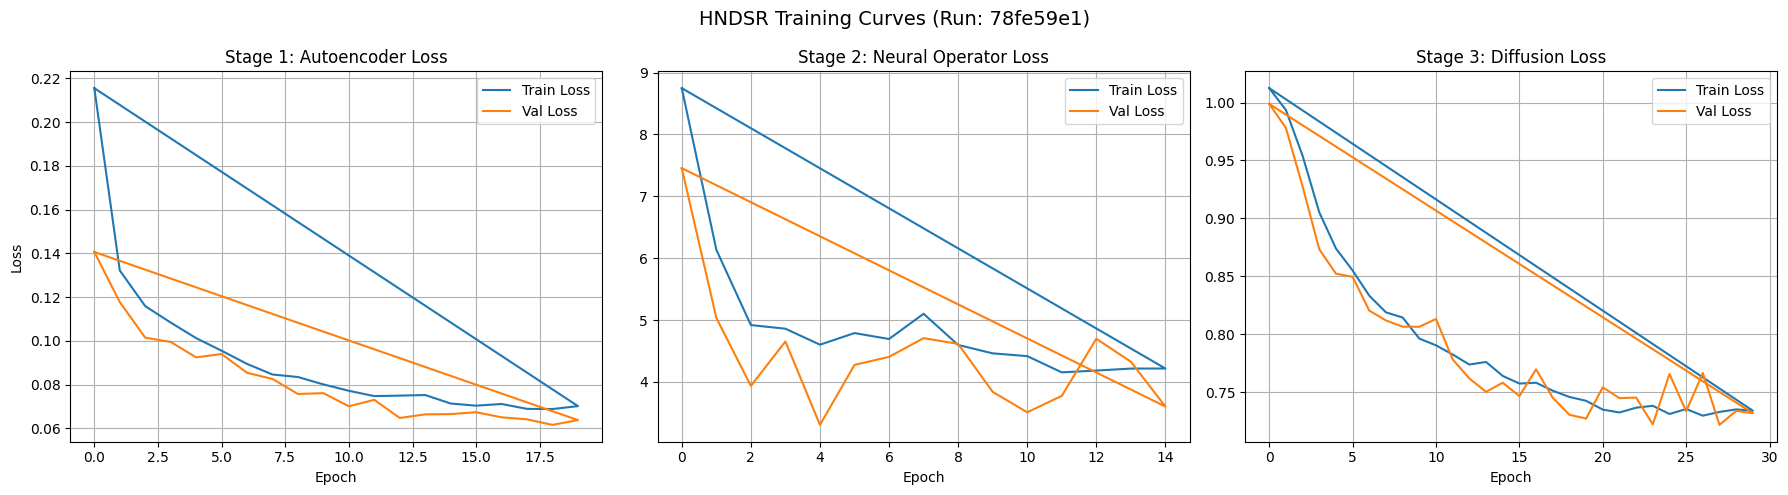


✅ Saved training_curves.png to c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow


In [24]:
# Cell 22: Plot Training Loss Curves from MLflow
import matplotlib.pyplot as plt

experiment = mlflow.get_experiment_by_name('HNDSR_SuperResolution')
if experiment:
    runs = mlflow.search_runs(experiment_ids=[experiment.experiment_id],
                              order_by=['start_time DESC'], max_results=1)

    if len(runs) > 0:
        run_id = runs.iloc[0]['run_id']
        client = mlflow.tracking.MlflowClient()

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Stage 1
        try:
            s1_train = client.get_metric_history(run_id, 'stage1_train_loss')
            s1_val = client.get_metric_history(run_id, 'stage1_val_loss')
            axes[0].plot([m.step for m in s1_train], [m.value for m in s1_train], label='Train Loss')
            axes[0].plot([m.step for m in s1_val], [m.value for m in s1_val], label='Val Loss')
            axes[0].set_title('Stage 1: Autoencoder Loss')
            axes[0].set_xlabel('Epoch')
            axes[0].set_ylabel('Loss')
            axes[0].legend()
            axes[0].grid(True)
        except:
            axes[0].text(0.5, 0.5, 'No Stage 1 data', ha='center', va='center')

        # Stage 2
        try:
            s2_train = client.get_metric_history(run_id, 'stage2_train_loss')
            s2_val = client.get_metric_history(run_id, 'stage2_val_loss')
            axes[1].plot([m.step for m in s2_train], [m.value for m in s2_train], label='Train Loss')
            axes[1].plot([m.step for m in s2_val], [m.value for m in s2_val], label='Val Loss')
            axes[1].set_title('Stage 2: Neural Operator Loss')
            axes[1].set_xlabel('Epoch')
            axes[1].legend()
            axes[1].grid(True)
        except:
            axes[1].text(0.5, 0.5, 'No Stage 2 data', ha='center', va='center')

        # Stage 3
        try:
            s3_train = client.get_metric_history(run_id, 'stage3_train_loss')
            s3_val = client.get_metric_history(run_id, 'stage3_val_loss')
            axes[2].plot([m.step for m in s3_train], [m.value for m in s3_train], label='Train Loss')
            axes[2].plot([m.step for m in s3_val], [m.value for m in s3_val], label='Val Loss')
            axes[2].set_title('Stage 3: Diffusion Loss')
            axes[2].set_xlabel('Epoch')
            axes[2].legend()
            axes[2].grid(True)
        except:
            axes[2].text(0.5, 0.5, 'No Stage 3 data', ha='center', va='center')

        plt.suptitle(f'HNDSR Training Curves (Run: {run_id[:8]})', fontsize=14)
        plt.tight_layout()
        plt.savefig(os.path.join(MLFLOW_DIR, 'training_curves.png'), dpi=150)
        plt.show()
        print(f"\n✅ Saved training_curves.png to {MLFLOW_DIR}")
    else:
        print('⚠️  No runs found.')
else:
    print('⚠️  Experiment not found. Run training first.')

---
## Cell 23: Load Checkpoints & Re-evaluate

Utility to reload a previously trained model from saved checkpoints and run evaluation without retraining.

**Line-by-line breakdown:**

- **`load_complete_model(checkpoint_path, device)`:**
  - Creates a fresh `HNDSR()` instance with the same hyperparameters.
  - Loads each component's `state_dict` from the combined `.pth` file.
  - Moves all components to the target device.
  - Returns the fully loaded model ready for inference.

- **Usage block:**
  - Checks if `COMPLETE_MODEL_PATH` exists (training was run previously).
  - If found, loads the model and runs `evaluate_model()` on the test set.
  - Useful for re-evaluating after a kernel restart without retraining.

In [34]:
# Cell 23: Load Trained Model and Evaluate
def load_complete_model(checkpoint_path=None, device='cuda'):
    """Load the complete trained model from checkpoint"""
    if checkpoint_path is None:
        checkpoint_path = COMPLETE_MODEL_PATH

    print("\n" + "="*60)
    print("LOADING COMPLETE MODEL")
    print("="*60)

    model = HNDSR(
        ae_latent_dim=128,
        ae_downsample_ratio=8,
        no_width=32,
        no_modes=8,
        diffusion_channels=64,
        num_timesteps=1000
    )

    checkpoint = torch.load(checkpoint_path, map_location=device)

    model.autoencoder.load_state_dict(checkpoint['autoencoder'])
    model.neural_operator.load_state_dict(checkpoint['neural_operator'])
    model.diffusion_unet.load_state_dict(checkpoint['diffusion_unet'])
    model.implicit_amp.load_state_dict(checkpoint['implicit_amp'])

    model.autoencoder.to(device)
    model.neural_operator.to(device)
    model.implicit_amp.to(device)
    model.diffusion_unet.to(device)

    print("✅ Model loaded successfully!")
    print("="*60)

    return model


# Example usage:
if os.path.exists(COMPLETE_MODEL_PATH):
    if HR_DIR and LR_DIR:
        print("✅ Trained model found! Running evaluation...")
        eval_model = load_complete_model(COMPLETE_MODEL_PATH, device)

        test_dataset = SatelliteDataset(HR_DIR, LR_DIR, patch_size=64, training=False)
        num_samples = min(50, len(test_dataset))
        if len(test_dataset) > num_samples:
            indices = np.random.choice(len(test_dataset), num_samples, replace=False)
            test_dataset = torch.utils.data.Subset(test_dataset, indices)
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

        results = evaluate_model(eval_model, test_loader, device,
                                save_results=True, output_dir=EVAL_RESULTS_DIR)
    else:
        print("⚠️  Set HR_DIR and LR_DIR first.")
else:
    print(f"⚠️  No model found at {COMPLETE_MODEL_PATH}. Run training first.")

✅ Trained model found! Running evaluation...

LOADING COMPLETE MODEL
✅ Model loaded successfully!
Found 360 image pairs
Sample HR: austin1.tif
Sample LR: austin1.tif
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: C:\Users\harsh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\lpips\weights\v0.1\alex.pth

EVALUATING MODEL ON TEST SET


Evaluating: 100%|██████████| 50/50 [00:06<00:00,  8.11it/s]


FINAL RESULTS
📊 PSNR: 23.48 ± 3.25 dB
📊 SSIM: 0.5700 ± 0.1224
📊 LPIPS: 0.4809 ± 0.1053

✅ Results saved to 'c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow\evaluation_results/'
✅ Metrics saved to 'c:\Users\harsh\OneDrive - Indian Institute of Information Technology, Nagpur\IIIT Nagpur\5th Semester\Mini Project\MLFlow\evaluation_results/evaluation_results.pth'


---
## Launch MLflow UI

To visualize all experiments, metrics, and artifacts in a browser dashboard:

```bash
cd MLFlow
mlflow ui
```

Then open **http://127.0.0.1:5000** in your browser.

**What you'll see:**
- **Experiments list** — All HNDSR runs with status, start time, and duration
- **Metrics tab** — Interactive loss curves for all three stages
- **Parameters tab** — Full hyperparameter comparison across runs
- **Artifacts tab** — Checkpoints, evaluation images, comparison grids
- **Model Registry** — Versioned models ready for deployment